# Lesson 1A: Logistic Regression Theory

<a name="introduction"></a>
## Introduction

Logistic regression can be most easily thought of as learning to pick ripe fruit when you were a child.

Whether it was apples, oranges, mangoes or rambutan - you'd follow a few simple rules: "if it has the right color, feels slightly soft when squeezed, and has a sweet aroma, it's ready to eat".

Essentially, you were converting multiple continuous measurements into a single yes/no decision. After a few weeks of practice, you were able to pick ripe fruit with 90% accuracy.

That's logistic regression in its purest form - taking several measurements (like the percentage of red colour, firmness level, and aroma strength) and combining them to make binary decisions (ripe or not ripe).

In this lesson, we'll:

1. Learn the theory behind logistic regression
2. Build a logistic regression model from scratch to deeply understand each component
3. Apply it to the Wisconsin Breast Cancer dataset
4. Establish key machine learning concepts to prepare us for more advanced models

Then in the next lesson (1b), we'll:
1. Use the widely-used PyTorch library to implement the same model more efficiently
2. Learn best practices for production machine learning
3. Compare our implementation with PyTorch's optimised version

## Table of contents

1. [Introduction](#introduction)
2. [Required libraries](#required-libraries)
3. [What is logistic regression?](#what-is-logistic-regression)
4. [How logistic regression works](#how-logistic-regression-works)
   - [Step 1: Linear combination](#step-1-linear-combination)
   - [Step 2: Sigmoid function](#step-2-sigmoid-function)
   - [Step 3: Making a prediction](#step-3-making-a-prediction)
   - [Logistic regression visualisation](#logistic-regression-visualisation)
     - [2D decision boundary - 2 features](#2d-decision-boundary---2-features)
     - [3D decision boundary - 3 features](#3d-decision-boundary---3-features)
     - [Hyperplane in higher dimensions - n features](#hyperplane-in-higher-dimensions---n-features)
5. [The training process: Learning to spot cancer](#the-training-process-learning-to-spot-cancer)
   - [Understanding feature importance](#understanding-feature-importance)
   - [Combining features](#combining-features)
   - [Converting to mathematics](#converting-to-mathematics)
   - [Visualising the learning process](#visualising-the-learning-process)
   - [Understanding our results](#understanding-our-results)
   - [The problem - different scales](#the-problem-different-scales)
   - [Nature's solution: normal distributions](#natures-solution-normal-distributions)
   - [Making measurements comparable](#making-measurements-comparable)
6. [Learning the right weights](#learning-the-right-weights)
   - [The training approach](#the-training-approach)
   - [Choosing our initial weights](#choosing-our-initial-weights)
   - [Making our first prediction](#making-our-first-prediction)
   - [Converting score to probability](#converting-score-to-probability)
   - [Prediction vs actual outcome](#prediction-vs-actual-outcome)
   - [Converting error to loss](#converting-error-to-loss)
   - [Binary cross-entropy loss](#binary-cross-entropy-loss)
   - [Asymmetric loss: when mistakes aren't equal](#asymmetric-loss-when-mistakes-arent-equal)
7. [Gradient descent: Learning from our errors](#gradient-descent-learning-from-our-errors)
   - [Step 1: Starting position and "The Forward Pass"](#step-1-starting-position-and-the-forward-pass)
   - [Step 2: Sigmoid activation - Making a prediction](#step-2-sigmoid-activation---making-a-prediction)
   - [Step 3: Measuring the error](#step-3-measuring-the-error)
   - [Step 4: Calculating the gradient of loss for each parameter](#step-4-calculating-the-gradient-of-loss-for-each-parameter)
   - [Step 4: The calculus - How gradient of loss is derived for each parameter](#step-4---the-calculus-how-gradient-of-loss-with-respect-to-each-parameter-is-derived-using-the-chain-rule)
   - [Step 5: Calculating the amount to update each parameter by](#step-5-calculating-the-amount-to-update-each-parameter-by)
   - [Step 6: Updating the parameters](#step-6-updating-the-parameters)
   - [Second pass - Step 1 again](#second-pass---step-1-again)
   - [The learning process](#the-learning-process)
8. [Implementing logistic regression: from theory to code](#implementing-logistic-regression-from-theory-to-code)
9. [Understanding our training results through evaluation](#understanding-our-training-results-through-evaluation)
   - [Key outcomes](#key-outcomes)
   - [Medical interpretation](#medical-interpretation)
10. [Basic evaluation concepts](#basic-evaluation-concepts)
    - [Accuracy](#1-accuracy)
    - [Precision](#2-precision)
    - [Recall (Sensitivity)](#3-recall-sensitivity)
    - [F1 score](#4-f1-score)
    - [The four possible outcomes](#the-four-possible-outcomes)
    - [The problem with simple accuracy](#the-problem-with-simple-accuracy)
    - [The confusion matrix](#the-confusion-matrix)
11. [Understanding our model's performance](#understanding-our-models-performance)
12. [Understanding learning rate effects](#understanding-learning-rate-effects)
    - [Reading the loss curves](#reading-the-loss-curves)
    - [Understanding the clinical impact](#understanding-the-clinical-impact)
    - [Theoretical insights vs clinical reality](#theoretical-insights-vs-clinical-reality)
    - [Key lessons about machine learning](#key-lessons-about-machine-learning)
    - [In practice: A note of caution](#in-practice-a-note-of-caution)
    - [The big picture](#the-big-picture)
13. [Conclusion: Our journey through logistic regression](#conclusion-our-journey-through-logistic-regression)
    - [Looking ahead to lesson 1B](#looking-ahead-to-lesson-1b)
    - [Further reading](#further-reading)

<a name="required-libraries"></a>
## Required libraries

Before we get started, let's load the necessary libraries that will be used throughout this lesson in our theory examples.

In this lesson we will use the following libraries:
<table style="margin-left:0">
<tr>
<th align="left">Library</th>
<th align="left">Purpose</th>
</tr>
<tr>
<td>Pandas</td>
<td>Data tables and data manipulation</td>
</tr>
<tr>
<td>Numpy</td>
<td>Numerical computing functions</td>
</tr>
<tr>
<td>Matplotlib</td>
<td>Plotting functions</td>
</tr>
<tr>
<td>Seaborn</td>
<td>Statistical visualisation</td>
</tr>
<tr>
<td>Scikit-learn</td>
<td>Machine learning utilities including logistic regression, preprocessing, metrics, and dataset loading functions</td>
</tr>
<tr>
<td>Typing</td>
<td>Type hints</td>
</tr>
</table>

In [1]:
# Standard library imports
from typing import List, Optional, Union, Tuple

# Third party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.typing import NDArray
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Jupyter specific
%matplotlib inline

# Configure settings
np.random.seed(42)
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

from IPython.core.display import HTML
table_css = 'table {align:left;display:block} '
HTML('<style>{}</style>'.format(table_css))

print("Libraries imported successfully!")

Libraries imported successfully!


<a name="what-is-logistic-regression"></a>
## What is logistic regression?

Formally, logistic regression is a statistical model that estimates the probability of a binary outcome based on one or more input variables.

Despite its name, logistic regression is a classification algorithm, not a regression algorithm. It estimates the probability of a binary outcome (yes/no, true/false, 1/0) based on one or more input variables.

At its most basic level, the logistic regression algorithm follows 4 key steps:
1. Takes in numeric measurements (like temperature, age, or price)
2. Combines them in a clever way to calculate a score
3. Converts this score into a probability between 0 and 1
4. Makes a yes/no decision based on whether that probability exceeds 0.5

The "regression" in its name comes from how it finds relationships between input features and the probability of the outcome. It uses a special function called the sigmoid (or logistic function) to transform linear predictions into probabilities.

Before diving into the implementation, let's understand the core mathematical concepts that make this possible.

<a name="how-logistic-regression-works"></a>
## How logistic regression works

Logistic regression works by finding a mathematical relationship between the input data and the probability of the outcome being a binary outcome - a "yes" or "no", 1 or 0, true or false.

Logistic regression does this by following three key steps:

1. **Linear Combination**: First we combine input features by multiplying each one by a learned weight and adding a bias term to obtain a score.

2. **Sigmoid Function**: Then we convert the score to a probability using the sigmoid function.

3. **Decision Rule**: Finally we convert the probability into a yes/no prediction by setting a threshold (typically 0.5).

\
Let's work through a medical diagnosis example to see logistic regression in action. We'll use three key features:

```
Patient Data:
- Age: 45
- Blood Pressure: 128/82
- Cholesterol: 240
```

<a name="step-1-linear-combination"></a>
### Step 1: Linear combination

First, logistic regression combines all input features by multiplying each one by a learned weight and intially these weights are random values:


### $z = w_1x_1 + w_2x_2 + ... + w_nx_n + b$


Here:
- `x1`, `x2`, ..., `xn` are the input features values - in this example: age (years), systolic blood pressure (mmHg), total cholesterol (mg/dL).
- `w1`, `w2`, ..., `wn` are the weights - values that indicates how important each feature is.
- `b` is the bias term - a value that indicates the base prediction level, like a doctor's starting suspicion. In this example, we'll set it to 0.

#### For our medical example:

**Initial weights and bias:**

### $w_1 = 0.03, w_2 = 0.02, w_3 = 0.01, b = 0$

**Linear combination:**

### $z = 0.03 \times \text{age} + 0.02 \times blood\_pressure + 0.01 \times \text{cholesterol} + 0$
### $z = 0.03 \times 45 + 0.02 \times 128 + 0.01 \times 240 + 0$
### $z = 1.35 + 2.56 + 2.40 + 0$
### $z = 6.31$


This gives us a number that could be any value from negative infinity to positive infinity.

To turn this into a probability, we need the sigmoid function.

<a name="step-2-sigmoid-function"></a>
### Step 2: Sigmoid function

The result of the linear combination (`z`) could be any number from negative infinity to positive infinity, but we want a probability between 0 and 1. To achieve this, we pass `z` through a special mathematical function called the sigmoid function:


### $p = \frac{1}{1 + e^{-z}}$

Here, `e` is Euler's number (approximately 2.71828), also known as the base of natural logarithms.

The sigmoid function squashes `z` into a value between 0 and 1, which we can interpret as the probability of the outcome being "yes". For our example:

### $p = \frac{1}{1 + e^{-6.31}}$
### $p = \frac{1}{1 + 0.00182}$
### $p = 0.998$

In this example, our calculation determines that the probability of the patient being at high risk of disease is 99.8%.

The sigmoid function has several important properties:

1. Always outputs values between 0 and 1
2. Centered at 0.5 (when input is 0)
3. S-shaped curve captures natural probability thresholds

![Sigmoid Curve](https://github.com/powell-clark/supervised-machine-learning/blob/main/static/images/sigmoid-curve.png?raw=1)

Let's visualise the sigmoid function in python:

<a name="log-odds-the-inverse-of-sigmoid"></a>
### Log-odds (the inverse of sigmoid)

The sigmoid function has an inverse, called the **logit** function, which recovers
$z$ from a probability $p$:

$$z = \text{logit}(p) = \ln\!\left(\frac{p}{1-p}\right)$$

The ratio $\frac{p}{1-p}$ is the **odds** of the outcome (how many times more likely
"yes" is than "no"), so $z$ itself is the **log-odds**. This is why $z$ (before the
sigmoid squashes it into a probability) is exactly what the linear combination of
features and weights is computing: logistic regression models the *log-odds* of the
outcome as a linear function of the inputs, $z = w \cdot x + b$, and only converts to
a probability at the very last step. For our example, $p = 0.998$ gives log-odds
$z = \ln(0.998 / 0.002) \approx 6.21$, close to the original $z=6.31$ (the small gap
is rounding in the displayed probability).

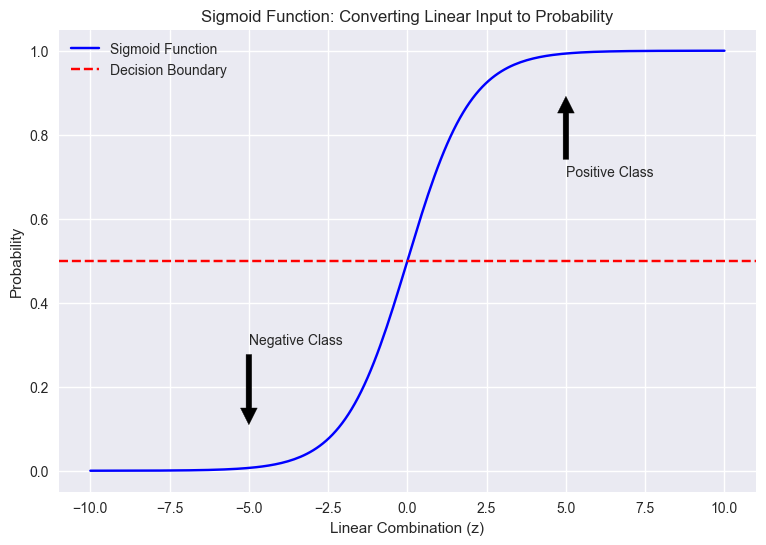

In [2]:
def sigmoid(x):
    """Convert input to probability between 0 and 1"""
    return 1 / (1 + np.exp(-x))

# Create range of input values
x = np.linspace(-10, 10, 200)
y = sigmoid(x)

# Plot sigmoid function
plt.figure(figsize=(9, 6))
plt.plot(x, y, 'b-', label='Sigmoid Function')
plt.axhline(y=0.5, color='r', linestyle='--', label='Decision Boundary')
plt.grid(True)
plt.title('Sigmoid Function: Converting Linear Input to Probability')
plt.xlabel('Linear Combination (z)')
plt.ylabel('Probability')
plt.legend()

# Add annotations
plt.annotate('Negative Class', xy=(-5, 0.1), xytext=(-5, 0.3),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate('Positive Class', xy=(5, 0.9), xytext=(5, 0.7),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()

<a name="step-3-making-a-prediction"></a>
### Step 3: Making a prediction

Finally, we convert the probability to a yes/no prediction using a threshold (usually 0.5):

```python
if probability > 0.5:
    prediction = "Yes" (Class 1)
else:
    prediction = "No" (Class 0)
```

For our medical example:
```
probability = 0.998 > 0.5
prediction = "Yes (Class 1) High risk of disease"
```

<a name="logistic-regression-visualisation"></a>
##  Logistic regression visualisation

Let's visualise this decision process with a simple 2D example in python showing the decision boundary for two features.

<a name="2d-decision-boundary---2-features"></a>
### 2D decision boundary - 2 features

/home/powell-clark/projects/auxiliary/supervised-learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


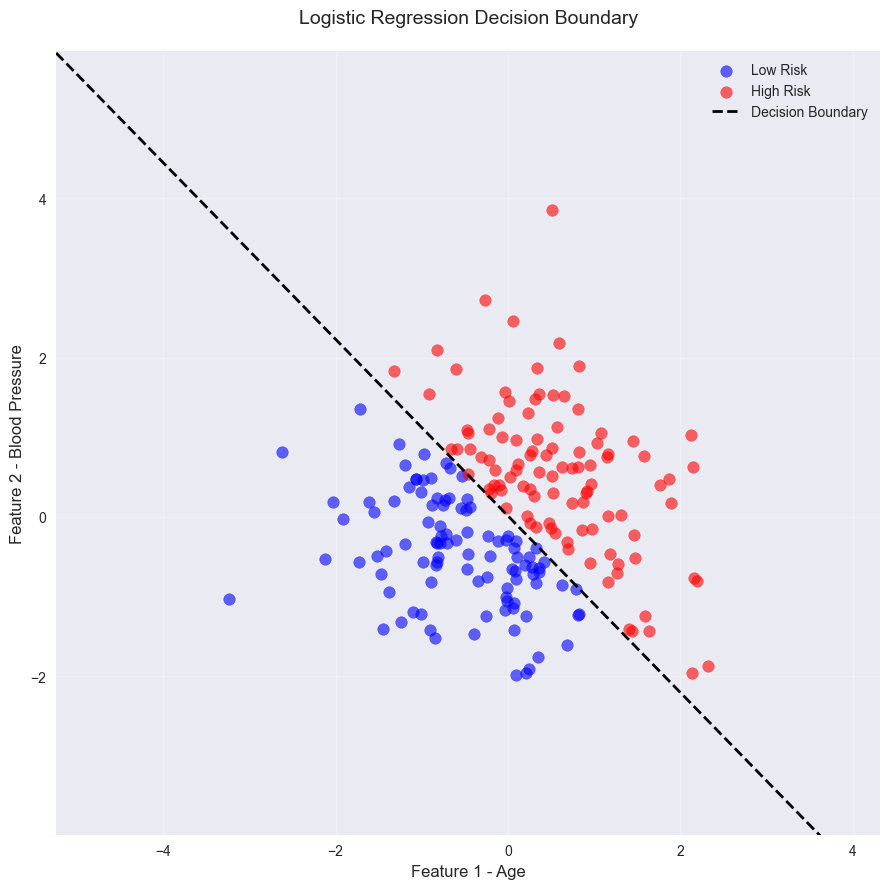

In [3]:
# Step 1: Create synthetic patient data
np.random.seed(42)  # For reproducible results
num_patients = 200
num_features = 2

# Generate random patient measurements
patient_features = np.random.randn(num_patients, num_features)

# Step 2: Create risk labels
patient_risk = (patient_features[:, 0] + patient_features[:, 1] > 0).astype(int)

# Step 3: Train the logistic regression model
risk_predictor = LogisticRegression()
risk_predictor.fit(patient_features, patient_risk)

# Step 4: Prepare the visualisation grid
padding = 2
feature1_min = patient_features[:, 0].min() - padding
feature1_max = patient_features[:, 0].max() + padding
feature2_min = patient_features[:, 1].min() - padding
feature2_max = patient_features[:, 1].max() + padding

# Step 5: Create the visualisation
plt.figure(figsize=(9, 9))

# Plot the actual patient data points
plt.scatter(patient_features[patient_risk==0][:, 0],
           patient_features[patient_risk==0][:, 1],
           color='blue',
           label='Low Risk',
           s=70,
           alpha=0.6)
plt.scatter(patient_features[patient_risk==1][:, 0],
           patient_features[patient_risk==1][:, 1],
           color='red',
           label='High Risk',
           s=70,
           alpha=0.6)

# Plot the decision boundary line
model_weights = risk_predictor.coef_[0]
model_bias = risk_predictor.intercept_[0]
boundary_x = np.array([feature1_min, feature1_max])
boundary_y = -(model_weights[0]*boundary_x + model_bias)/model_weights[1]
plt.plot(boundary_x, boundary_y, 'k--', linewidth=2, label='Decision Boundary')

# Add labels and formatting
plt.title('Logistic Regression Decision Boundary', fontsize=14, pad=20)
plt.xlabel('Feature 1 - Age', fontsize=12)
plt.ylabel('Feature 2 - Blood Pressure', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Ensure plot shows full range
plt.xlim(feature1_min, feature1_max)
plt.ylim(feature2_min, feature2_max)

plt.tight_layout()
plt.show()

This visualisation shows how logistic regression creates a linear decision boundary in the feature space.

Points below the line are classified as Class 0 - False (blue), and points above the line are Class 1 - True (red).

Patients were classified as high risk (1) because their features measurements sum to greater than zero. Patients were classified as low risk (0) because their features measurements sum to less than zero.

The dotted black line shows where the model's predicted probability equals 0.5, which is where the feature measurements sum to 0.

Key insights:
1. The decision boundary is always linear
2. Distance from boundary indicates prediction confidence
3. Points far from boundary have probabilities close to 0 or 1
4. Points near boundary have probabilities close to 0.5

<a name="3d-decision-boundary---3-features"></a>
#### 3D decision boundary - 3 features

In 3D space, the decision boundary becomes a plane.
The plane divides the 3D space into two regions, each corresponding to a class.

Let's visualise this decision process with a simple 3D example in python showing the decision boundary for three features.


/home/powell-clark/projects/auxiliary/supervised-learning/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


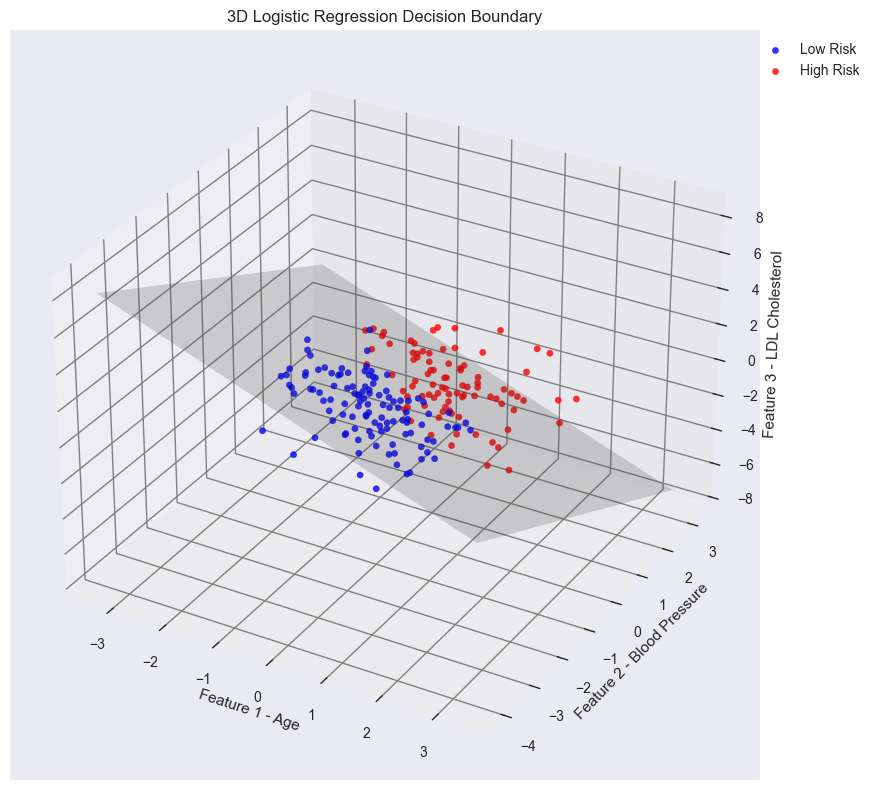

In [4]:
# 3D visualisation
def visualise_logistic_regression_3d():
    # Set random seed for reproducibility
    np.random.seed(0)

    # Generate random 3D data points
    feature_data = np.random.randn(200, 3)
    # Create binary labels based on sum of features
    labels = (feature_data[:, 0] + feature_data[:, 1] + feature_data[:, 2] > 0).astype(int)

    # Train logistic regression model
    logistic_model = LogisticRegression()
    logistic_model.fit(feature_data, labels)

    # Create 3D plot
    figure = plt.figure(figsize=(12, 8))
    axes_3d = figure.add_subplot(111, projection='3d')

    # Add grid lines for better visualisation
    axes_3d.grid(True, color='gray', linestyle='-', alpha=0.3)
    axes_3d.xaxis._axinfo["grid"]['color'] = 'gray'
    axes_3d.yaxis._axinfo["grid"]['color'] = 'gray'
    axes_3d.zaxis._axinfo["grid"]['color'] = 'gray'

    # Calculate decision boundary plane coordinates
    feature1_min, feature1_max = feature_data[:, 0].min() - 1, feature_data[:, 0].max() + 1
    feature2_min, feature2_max = feature_data[:, 1].min() - 1, feature_data[:, 1].max() + 1
    feature1_grid, feature2_grid = np.meshgrid(np.arange(feature1_min, feature1_max, 0.02),
                                              np.arange(feature2_min, feature2_max, 0.02))

    # Calculate feature3 values for decision boundary plane
    feature3_boundary = (-logistic_model.intercept_[0] -
                        logistic_model.coef_[0][0] * feature1_grid -
                        logistic_model.coef_[0][1] * feature2_grid) / logistic_model.coef_[0][2]

    # Plot decision boundary plane
    axes_3d.plot_surface(feature1_grid, feature2_grid, feature3_boundary, alpha=0.2, color='gray')

    # Plot data points colored by class
    axes_3d.scatter(feature_data[labels==0][:, 0],
                   feature_data[labels==0][:, 1],
                   feature_data[labels==0][:, 2],
                   color='blue', label='Low Risk', alpha=0.8)
    axes_3d.scatter(feature_data[labels==1][:, 0],
                   feature_data[labels==1][:, 1],
                   feature_data[labels==1][:, 2],
                   color='red', label='High Risk', alpha=0.8)

    # Add labels and title
    axes_3d.set_xlabel('Feature 1 - Age')
    axes_3d.set_ylabel('Feature 2 - Blood Pressure')
    axes_3d.set_zlabel('Feature 3 - LDL Cholesterol')
    axes_3d.set_title('3D Logistic Regression Decision Boundary')
    axes_3d.legend(bbox_to_anchor=(1.15, 1))

    plt.tight_layout()
    plt.show()

# Generate visualisation
visualise_logistic_regression_3d()


<a name="hyperplane-in-higher-dimensions---n-features"></a>
### Hyperplane in higher dimensions - n features

For datasets with more than 3 features, we can't visualise the decision boundary directly.

The concept extends to a hyperplane in higher-dimensional space.

A hyperplane in n-dimensional space is the subspace of dimension n-1 that divides the space into two parts.

![Mind Blowing](https://github.com/powell-clark/supervised-machine-learning/blob/main/static/images/mind-blowing.gif?raw=1)

### The equation of the hyperplane
   - For n features, the hyperplane is defined by the equation: $w_1 x_1 + w_2 x_2 + ... + w_n x_n + b = 0$
   - w1, w2, ..., wn are the weights learned by the model, and b is the bias term.

   **Look familiar? This is the same linear combination equation we saw at the start of the lesson!**

While we can't visualise beyond 3D, the same principle applies in higher dimensions - the model finds a hyperplane that best separates the classes in the feature space.

Now that we understand how logistic regression makes predictions, let's see how it chooses and learns the right weights and bias during training.

<a name="the-training-process-learning-to-spot-cancer"></a>
## The training process: Learning to spot cancer

<a name="understanding-feature-importance"></a>
### Understanding feature importance

Let's see how doctors learn to diagnose cancer by looking at two key features:

**Cell Size**
```
Normal Cell:  12mm across
Cancer Cell:  18mm across  (50% bigger - suspicious!)
```

**Cell Shape**
```
Normal Cell:  Smooth, round edges
Cancer Cell:  Rough, irregular edges (very suspicious!)
```

<a name="combining-features"></a>
### Combining features

After examining hundreds of cells, doctors learn that some patterns matter more than others:
```
Pattern                     Likely Diagnosis
-------------------         ----------------
Big + Smooth                Probably benign
Normal + Very irregular     Likely cancer

Key Learning: Shape irregularity is a stronger indicator than size!
```

<a name="converting-to-mathematics"></a>
### Converting to mathematics

We can translate the doctor's knowledge into weights:
```
Doctor's Rule               Mathematical Version
-------------               -------------------
Size matters some    →      Size × 0.3
Shape matters more   →      Shape × 0.7

Decision Rule: If (Size × 0.3 + Shape × 0.7) > 4.41: Suspicious!
```

<a name="visualising-the-learning-process"></a>
### Visualising the learning process

Let's create a dataset of 200 cells (100 normal, 100 cancerous) and analyse how these features help us distinguish between them:

1. **Size Distribution**    - First, we'll look at how cell sizes differ between normal and cancerous cells
2. **Shape Distribution**   - Then, we'll examine the shape irregularity patterns
3. **Combined View**        - We'll plot size against shape to see how they work together
4. **Final Score**          - Finally, we'll see how combining these features (0.3×Size + 0.7×Shape) helps separate the two groups


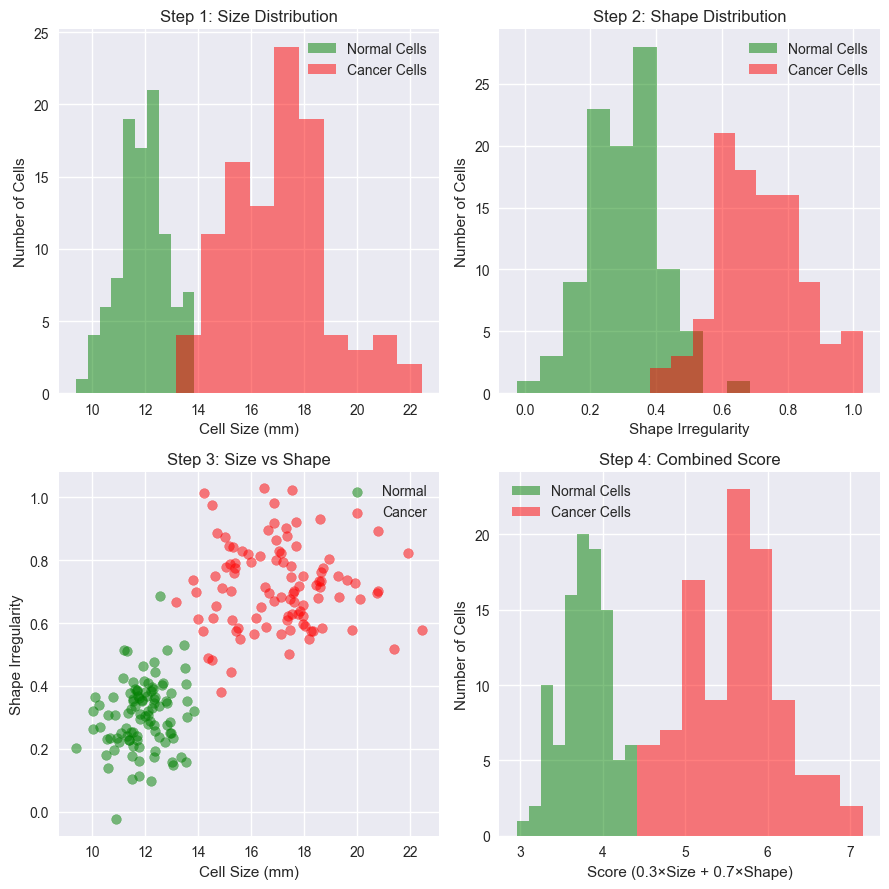

In [5]:
# This code creates a dataset of normal and cancerous cells with different size and shape irregularity scores
# Then presents the distribution of

# Create sample data for demonstration
np.random.seed(42)

# Generate two groups of cells
normal_size = np.random.normal(12, 1, 100)  # Normal cells: mean 12mm
cancer_size = np.random.normal(17, 2, 100)  # Cancer cells: mean 17mm

# Create corresponding shape irregularity scores
normal_shape = np.random.normal(0.3, 0.1, 100)  # More regular
cancer_shape = np.random.normal(0.7, 0.15, 100) # More irregular

# Create figure with 4 subplots in 2x2 layout
plt.figure(figsize=(9, 9))

# Plot 1: Size Distribution bar chart of normal and cancerous cells
plt.subplot(221)
plt.hist(normal_size, alpha=0.5, color='green', label='Normal Cells')
plt.hist(cancer_size, alpha=0.5, color='red', label='Cancer Cells')
plt.title('Step 1: Size Distribution')
plt.xlabel('Cell Size (mm)')
plt.ylabel('Number of Cells')
plt.legend()

# Plot 2: Shape Distribution bar chart of normal and cancerous cells
plt.subplot(222)
plt.hist(normal_shape, alpha=0.5, color='green', label='Normal Cells')
plt.hist(cancer_shape, alpha=0.5, color='red', label='Cancer Cells')
plt.title('Step 2: Shape Distribution')
plt.xlabel('Shape Irregularity')
plt.ylabel('Number of Cells')
plt.legend()

# Plot 3: Size vs Shape Scatter with normal and cancerous cells labelled
plt.subplot(223)
plt.scatter(normal_size, normal_shape, alpha=0.5, color='green', label='Normal')
plt.scatter(cancer_size, cancer_shape, alpha=0.5, color='red', label='Cancer')
plt.title('Step 3: Size vs Shape')
plt.xlabel('Cell Size (mm)')
plt.ylabel('Shape Irregularity')
plt.legend()

# Plot 4: Combined Score bar chart of normal and cancerous cells
plt.subplot(224)
normal_score = 0.3 * normal_size + 0.7 * normal_shape
cancer_score = 0.3 * cancer_size + 0.7 * cancer_shape
plt.hist(normal_score, alpha=0.5, color='green', label='Normal Cells')
plt.hist(cancer_score, alpha=0.5, color='red', label='Cancer Cells')
plt.title('Step 4: Combined Score')
plt.xlabel('Score (0.3×Size + 0.7×Shape)')
plt.ylabel('Number of Cells')
plt.legend()

plt.tight_layout()
plt.show()

<a name="understanding-our-results"></a>
### 5. Understanding our results

Looking at our four plots reveals the challenge of combining features:

1. **Size Distribution** (top left):
   - Normal cells cluster around 12mm (green)
   - Cancer cells cluster around 17mm (red)
   - Significant overlap between 13-14mm
<br>
2. **Shape Distribution** (top right):
   - Normal cells have regularity around 0.3 (green)
   - Cancer cells have irregularity around 0.7 (red)
   - Clear separation but still some overlap
<br>
3. **Size vs Shape** (bottom left):
   - Clear clustering pattern emerges
   - Normal cells: small + regular (bottom left, green)
   - Cancer cells: large + irregular (top right, red)
   - We see a clear separation between the two classes
<br>
4. **Combined Score** (bottom right):
   - Formula: 0.3×Size + 0.7×Shape
   - Normal scores cluster around 4.0
   - Cancer scores cluster around 6.0
   - We can imagine a decision boundary at 4.41
<br>

<a name="the-problem-different-scales"></a>
### The problem: Different scales

Our measurements live in different orders of magnitude:
- Size: Typically 10-20 millimeters
- Shape: Always between 0-1

Size dominates our equation just because it uses bigger numbers!

<a name="natures-solution-normal-distributions"></a>
### Nature's solution: Normal distributions

<img alt="Normal Distribution" src="https://github.com/powell-clark/supervised-machine-learning/blob/main/static/images/normal-distribution.jpg?raw=1" width="875"/>

Here's something remarkable about biology: most measurements follow a 'normal distribution'.

<img alt="Height Normal Distribution" src="https://github.com/powell-clark/supervised-machine-learning/blob/main/static/images/height-normal-distribution.png?raw=1" width="875"/>

For cell size:
- Most cells cluster around an average (μ)
- Variation is predictable (measured by σ)
- Very few cells are more than 3σ from average

This pattern appears in both size AND shape measurements!

<a name="making-measurements-comparable"></a>
### Making measurements comparable

We can use this natural pattern to standardise our measurements
### Standard Deviation (σ) = $\sqrt{\frac{\sum_{i=1}^{n} (x_i - \mu)^2}{n}}$
```
Where:
- σ is the standard deviation
- x_i is each value in the dataset
- μ is the mean of the dataset
- n is the number of values
```

### Standardised Value = $ \frac{value - average}{standard\_deviation}$
### Standardised Value = $\frac{x - \mu}{\sigma}$

This tells us: "How many standard deviations away from normal?"

Now our measurements speak the same language:
```
Original → Standardised (σ units)

Cancer Cell:
18mm   → +2.1  (2.1σ above normal size)
0.8    → +1.9  (1.9σ above normal shape)

Normal Cell:
16mm   → +0.8  (0.8σ above normal size)
0.3    → -0.7  (0.7σ below normal shape)
```


#### Now we can learn properly!

With standardised values:
1. Size and shape are comparable
2. We can find true importance (weights)
3. Numbers have biological meaning

#### Let's compare our raw measurements dataset and a standardised measurements data set
- Intial weights of both features will be 0.5 and no bias so the output of the linear combination will be: Combined score $(z) = 0.5 \times feature_1 + 0.5 \times feature_2 + 0$
- We'll see how the output of combined score $(z) = w_1x_1 + w_2x_2 + b$, changes for both our datasets

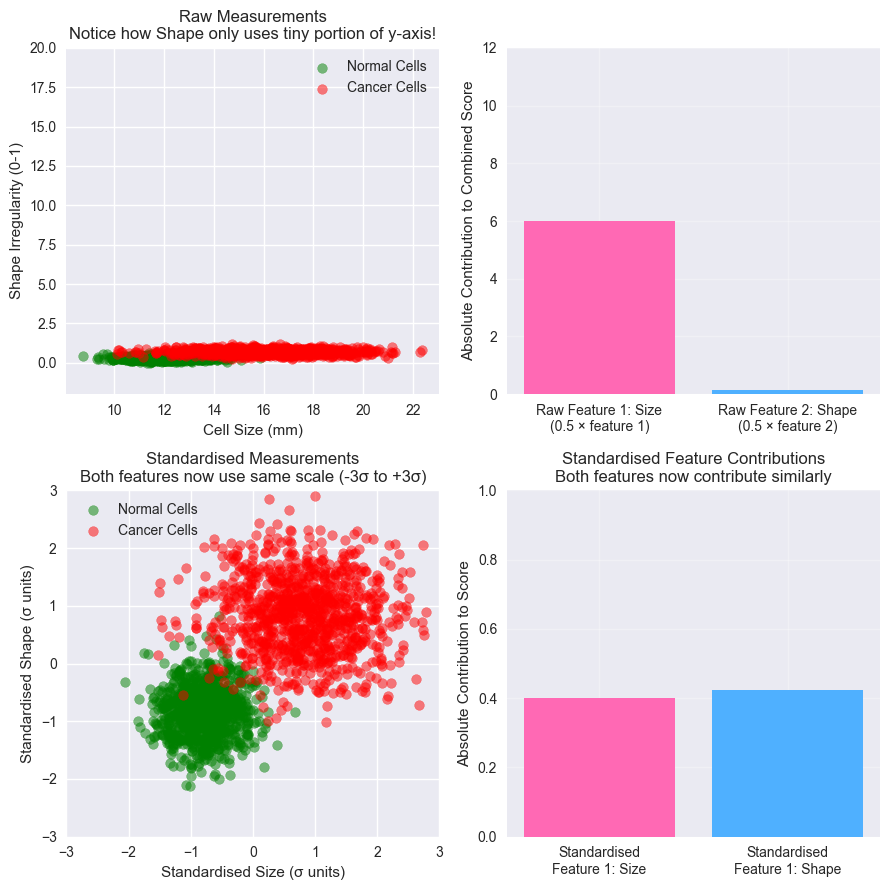


Average Absolute Raw Contributions to Combined Score (z)
--------------------------------------------------
Size term (0.5 × size): 6.01
Shape term (0.5 × shape): 0.15
Size term is 40.0x larger than shape term!

Average Absolute Standardised Contributions to Combined Score (z)
--------------------------------------------------
Standardised size term: 0.40
Standardised shape term: 0.42
Ratio between terms: 0.95x


In [6]:
# Generate sample data
np.random.seed(42)
n_samples = 1000

# Generate realistic cell measurements
normal_size = np.random.normal(12, 1, n_samples)
cancer_size = np.random.normal(16, 2, n_samples)
normal_shape = np.random.normal(0.3, 0.1, n_samples)
cancer_shape = np.random.normal(0.7, 0.15, n_samples)

# Colors
size_color = '#FF69B4'  # Pink
shape_color = '#4FB0FF'  # Light blue

fig, axes = plt.subplots(2, 2, figsize=(9, 9))

# Plot 1: Raw Measurements Scatter - FIXED SCALE to show true relationship
axes[0,0].scatter(normal_size, normal_shape, alpha=0.5, c='green', label='Normal Cells')
axes[0,0].scatter(cancer_size, cancer_shape, alpha=0.5, c='red', label='Cancer Cells')
axes[0,0].set_title('Raw Measurements\nNotice how Shape only uses tiny portion of y-axis!')
axes[0,0].set_xlabel('Cell Size (mm)')
axes[0,0].set_ylabel('Shape Irregularity (0-1)')
axes[0,0].set_ylim(-2, 20)  # Force same scale as x-axis to show true scale difference
axes[0,0].legend()
axes[0,0].grid(True)

# Plot 2: Raw feature contributions
size_contribution = np.abs(0.5 * normal_size).mean()
shape_contribution = np.abs(0.5 * normal_shape).mean()

# Simple bar plot showing relative scales with fixed y-axis
axes[0,1].bar(['Raw Feature 1: Size\n(0.5 × feature 1)', 'Raw Feature 2: Shape\n(0.5 × feature 2)'],
              [size_contribution, shape_contribution],
              color=[size_color, shape_color])
axes[0,1].set_ylabel('Absolute Contribution to Combined Score')
axes[0,1].set_ylim(0, 12)  # Fixed scale to show full context
axes[0,1].grid(True, alpha=0.3)

# Standardise ALL data together
all_sizes = np.concatenate([normal_size, cancer_size])
all_shapes = np.concatenate([normal_shape, cancer_shape])

def standardise(x):
    return (x - np.mean(x)) / np.std(x)

std_sizes = standardise(all_sizes)
std_shapes = standardise(all_shapes)

# Split back into normal/cancer
std_sizes_normal = std_sizes[:n_samples]
std_sizes_cancer = std_sizes[n_samples:]
std_shapes_normal = std_shapes[:n_samples]
std_shapes_cancer = std_shapes[n_samples:]

# Plot 3: Standardized Measurements Scatter
axes[1,0].scatter(std_sizes_normal, std_shapes_normal, alpha=0.5, c='green', label='Normal Cells')
axes[1,0].scatter(std_sizes_cancer, std_shapes_cancer, alpha=0.5, c='red', label='Cancer Cells')
axes[1,0].set_title('Standardised Measurements\nBoth features now use same scale (-3σ to +3σ)')
axes[1,0].set_xlabel('Standardised Size (σ units)')
axes[1,0].set_ylabel('Standardised Shape (σ units)')
axes[1,0].set_xlim(-3, 3)  # Set to standard normal range
axes[1,0].set_ylim(-3, 3)  # Set to standard normal range
axes[1,0].legend()
axes[1,0].grid(True)

# Plot 4: Standardized feature contributions
std_size_contribution = np.abs(0.5 * std_sizes_normal).mean()
std_shape_contribution = np.abs(0.5 * std_shapes_normal).mean()

axes[1,1].bar(['Standardised\nFeature 1: Size', 'Standardised\nFeature 1: Shape'],
              [std_size_contribution, std_shape_contribution],
              color=[size_color, shape_color])
axes[1,1].set_title('Standardised Feature Contributions\nBoth features now contribute similarly')
axes[1,1].set_ylabel('Absolute Contribution to Score')
axes[1,1].set_ylim(0, 1)  # Fixed scale for standardized values
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print example values
print("\nAverage Absolute Raw Contributions to Combined Score (z)")
print("-" * 50)
print(f"Size term (0.5 × size): {size_contribution:.2f}")
print(f"Shape term (0.5 × shape): {shape_contribution:.2f}")
print(f"Size term is {size_contribution/shape_contribution:.1f}x larger than shape term!")

print("\nAverage Absolute Standardised Contributions to Combined Score (z)")
print("-" * 50)
print(f"Standardised size term: {std_size_contribution:.2f}")
print(f"Standardised shape term: {std_shape_contribution:.2f}")
print(f"Ratio between terms: {std_size_contribution/std_shape_contribution:.2f}x")

Look at what standardisation does for us:

1. **Original Measurements** (top row)
   - Size and shape use completely different scales
   - Natural clusters difficult to distinguish because they are on different scales causing them to appear to overlap
<br>
2. **After Standardisation** (bottom row)
   - Both measurements in standard deviation (σ) units
   - Zero means "average"
   - ±1 means "one standard deviation difference"
   - Now we can fairly compare size and shape, and distinguish between each group!

This prepares us to learn proper weights because:
1. Size and shape now use same scale
2. Values show biological significance
3. Weights will reflect true importance

Now we're ready to learn!

Next, we'll see how to find the perfect weights using these standardised measurements and algebra.

<a name="learning-the-right-weights"></a>

## Learning the right weights

Now that our measurements are standardised, let's understand how our model learns to make diagnoses.

Just like a doctor learning to spot cancer, our model needs to learn which clues matter most.

<a name="the-training-approach"></a>
### The training approach

First, we split our data (569 samples) into the training data and the test data.
- The Training Data (80%):
   - Data used to train the model
      - 455 cells with known diagnoses
<br>
- The Testing Data (20%):
   - Data used to check how good our model is at making predictions
      - 114 cells with known diagnoses
      - Like the final exam
      - The model is not allowed to learn from these



<a name="choosing-our-initial-weights"></a>
### Choosing our initial weights

Just like a new medical student, our model starts with random weights, essentially random guesses about how important each feature is:

For our guesses we'll pick small random numbers between -0.5 and 0.5 for each weight and we'll keep bias at 0.

```
weight_size  = 0.3     # Weight for cell size
weight_shape = -0.4    # Weight for cell shape
bias         = 0       # Base suspicion level (bias)

```
Why small random numbers?
- Not too confident in any feature yet
- Room to learn in either direction
- Prevents extreme initial predictions

**Note: In production systems, we would most likely use the Xavier initialisation to choose our weights.**

The Xavier initialisation reduces the size of the weight ranges as the number of features increases.

When used with normalised inputs (mean=0, variance=1), this ensures the combined score z always has a variance of 1 around a mean of 0.

With this variance:
- 68% of z values fall between -1 and +1
- 95% of z values fall between -2 and +2
- 99.7% of z values fall between -3 and +3

This is particularly important for logistic regression because:
1. The sigmoid function is most sensitive between -3 and +3
2. The steepest gradient on the sigmoid function (which is best for learning) is around 0
3. Extreme z values (>|3|) cause vanishing gradients, slowing down training

```python
# Xavier initialisation
weight_range = sqrt(2.0 / n_features)
weights = random_uniform(-weight_range, weight_range)

# Example ranges for different numbers of features:
2 features:   random_uniform(-1.000, 1.000)    # sqrt(2/2)   -> Var(z) ≈ 1.000
6 features:   random_uniform(-0.577, 0.577)    # sqrt(2/6)   -> Var(z) ≈ 1.001
8 features:   random_uniform(-0.500, 0.500)    # sqrt(2/8)   -> Var(z) ≈ 0.999
10 features:  random_uniform(-0.447, 0.447)    # sqrt(2/10)  -> Var(z) ≈ 1.002
14 features:  random_uniform(-0.378, 0.378)    # sqrt(2/14)  -> Var(z) ≈ 0.998
18 features:  random_uniform(-0.333, 0.333)    # sqrt(2/18)  -> Var(z) ≈ 1.001
```

Going forward our example will stick with simple random numbers between -0.5 and 0.5 to make learning clearer!

<a name="making-our-first-prediction"></a>
### Making our first prediction

Let's look at how we predict for a single cell:
```
Example Cell #127:
Size  = +2.1σ                                     # Much bigger than normal
Shape = +1.9σ                                     # Very irregular shape


1. Gather Evidence:
   - Size is 2.1 standard deviations high
   - Shape is 1.9 standard deviations irregular

2. Multiple each feature by intial weight:
   weight_size  = 0.3                             # Random intial weight for cell size
   weight_shape = -0.4                            # Random intial Weight for cell shape

   size_score  = 0.3 × 2.1  = 0.63
   shape_score = -0.4 × 1.9 = -0.76

3. Combine Evidence:
   Bias = 0
   
   total_score (z) = size_score + shape_score + bias
                   = 0.63 + (-0.76) + 0
                   = -0.13
```

<a name="converting-score-to-probability"></a>
### Converting score to probability

Now we have a score (z) = -0.13, but what does that mean? We need to convert it to a probability between 0 and 1.

Nature gives us the perfect function for this - the sigmoid:
## $ p = \frac{1}{1 + e^{-z}} $
```
Where:
- e is Euler's number (≈ 2.71828)
- z is our score (-0.13)
```

For our example:
## $ p = \frac{1}{1 + e^{0.13}} $
## $ = \frac{1}{1 + 1.139} $
## $ = \frac{1}{2.139} $
## $ = 0.47 $
```
Translation:
- "47% chance of cancer"
-  Our decision boundary is 0.5 = 50%
-  So we predict benign / not cancer.
```

<a name="prediction-vs-actual-outcome"></a>
### Prediction vs actual outcome

Now we compare to the truth:
```
Predicted: 47% chance of cancer
Actual: Was cancer (100%)
```

**We were wrong!**

But... how wrong exactly?

This brings us to the central question: How do we measure wrongness?

<a name="converting-error-to-loss"></a>
### Converting error to loss

Let's start with the simplest measure of being wrong - absolute distance, the bigger the number the worse the error:

```
Simple Distance Error = |Actual outcome - Predicted outcome|
```
<br>
**When the sample is cancer (y=1):**

If the doctor says: "1% chance cancer" (p = 0.01)
```
Error = |1 - 0.01| = 0.99
```

If the doctor says: "50% chance cancer" (p = 0.50)
```  
Error = |1 - 0.50| = 0.50
```

If the doctor says: "99% chance cancer" (p = 0.99)
```
Error = |1 - 0.99| = 0.01
```
<br>
**When the sample is healthy (y=0):**

If the doctor says: "1% chance cancer" (p = 0.01)
```
Error = |0 - 0.01| = 0.01
```

If the doctor says: "50% chance cancer" (p = 0.50)
```
Error = |0 - 0.50| = 0.50
```

If the doctor says: "99% chance cancer" (p = 0.99)
```
Error = |0 - 0.99| = 0.99
```
<br>

#### Simple distance error vs model confidence visualisation

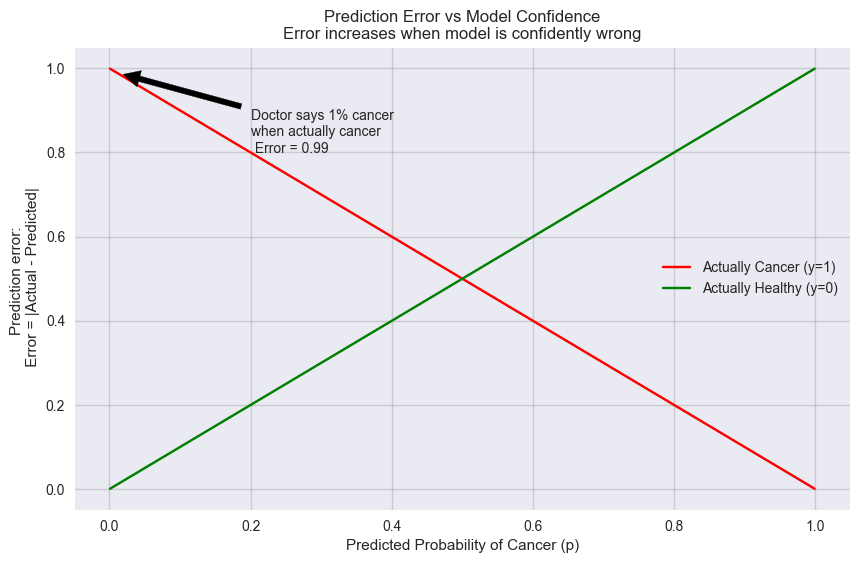

In [7]:
# Generate predictions from 0 to 1
probability_of_cancer_array = np.linspace(0.001, 0.999, 1000)

# Calculate mistakes for cancer case (y=1)
error_where_is_cancer_array = np.abs(1 - probability_of_cancer_array)

# Calculate mistakes for healthy case (y=0)
error_where_is_healthy_array = np.abs(0 - probability_of_cancer_array)

plt.figure(figsize=(10, 6))
plt.plot(probability_of_cancer_array, error_where_is_cancer_array, 'r-', label='Actually Cancer (y=1)')
plt.plot(probability_of_cancer_array, error_where_is_healthy_array, 'g-', label='Actually Healthy (y=0)')

plt.title('Prediction Error vs Model Confidence\nError increases when model is confidently wrong')
plt.xlabel('Predicted Probability of Cancer (p)')
plt.ylabel('Prediction error: \n Error = |Actual - Predicted|')

# Add annotations
plt.annotate('Doctor says 1% cancer\nwhen actually cancer\n Error = 0.99',
             xy=(0.01, 0.99), xytext=(0.2, 0.8),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Make grid more visible with custom properties
plt.grid(True, color='gray', linestyle='-', alpha=0.3)

plt.legend()
plt.show()

#### Simple distance error has three fundamental problems:

1. **Same gradient everywhere**
   - With absolute distance, moving from 0.1 to 0.0 (small error)
     gives the same guidance as moving from 0.9 to 0.8 (large error)
   - Both tell the model "change your weights by the same amount"
   - Like a coach who always just shouts "FASTER!" whether you're running 1% below
     target pace or 50% below target pace
<br>
2. **Unstable training**
   - Because the gradient of our prediction vs prediction error line is linear, the model takes fixed-size steps
   - Like seasoning soup with only a teaspoon:
     - too big a step when nearly perfect and we miss the target
     - too small when completely unsalted (takes forever)
<br>
3. **Weak penalties for bad predictions**
   - Being 90% confident and wrong should be punished more than being 51% confident and wrong
   - Example: If the doctor says "i'm 100% sure it's not cancer" when it is cancer this outcome should be penalised more heavily than "i'm 51% sure it's not cancer"
   - Simple distance treats these the same

#### Let's try squaring the error to solve these problems:
```
Squared Error = (Actual outcome - Predicted outcome)²
```

**Examples when Actually Cancer (y=1)**

Doctor says: "1% chance cancer" (p = 0.01)
```  
Error = (1 - 0.01)² = 0.98
```

Doctor says: "50% chance cancer" (p = 0.50)
```
Error = (1 - 0.50)² = 0.25
```

Doctor says: "99% chance cancer" (p = 0.99)
```
Error = (1 - 0.99)² = 0.0001
```

#### Squared distance error vs model confidence visualisation


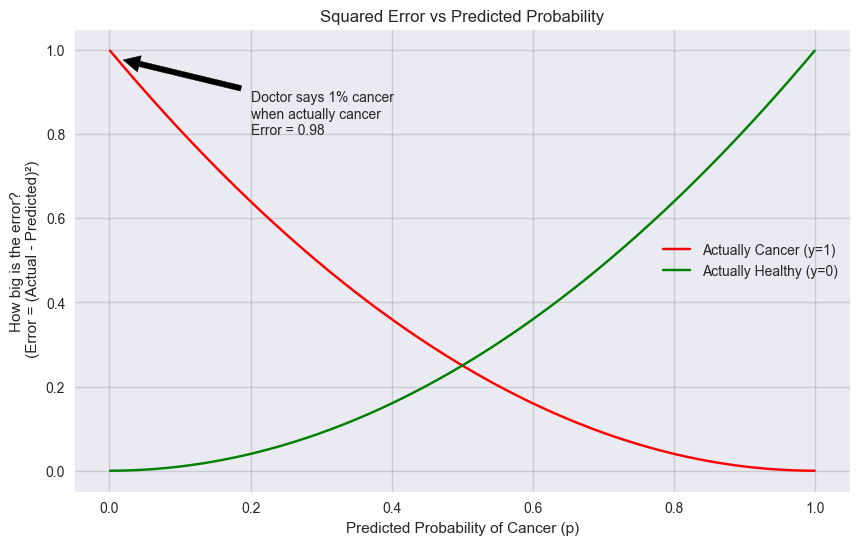

In [8]:
# Calculate squared mistakes
squared_errors_cancer = (1 - probability_of_cancer_array)**2
squared_errors_healthy = (0 - probability_of_cancer_array)**2

plt.figure(figsize=(10, 6))
plt.plot(probability_of_cancer_array, squared_errors_cancer, 'r-', label='Actually Cancer (y=1)')
plt.plot(probability_of_cancer_array, squared_errors_healthy, 'g-', label='Actually Healthy (y=0)')

plt.title('Squared Error vs Predicted Probability')
plt.xlabel('Predicted Probability of Cancer (p)')
plt.ylabel('How big is the error?\n (Error = (Actual - Predicted)²)')

plt.annotate('Doctor says 1% cancer\nwhen actually cancer\nError = 0.98',
             xy=(0.01, 0.98), xytext=(0.2, 0.8),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Make grid more visible with custom properties
plt.grid(True, color='gray', linestyle='-', alpha=0.3)
plt.grid(True)
plt.legend()
plt.show()

Squaring errors `(actual - predicted)²` helps penalise mistakes:
- It increases the penalty for confident wrong predictions
- It reduces the penalty for confident correct predictions

However, the quadratic scaling isn't ideal for classification tasks. When a doctor is very confident but wrong, we need a much stronger penalty than squared error provides.

### Logarithmic Loss

Log loss provides exponential penalties for confident mistakes, making it ideal for classification tasks like medical diagnosis:

```python
Log Loss = -log(p)         # when actually cancer
Log Loss = -log(1-p)       # when actually healthy
```
Examples when Actually Cancer (y=1):

Doctor says: "1% chance cancer" (p = 0.01)
```python
Loss = -log(0.01) = 4.61   # HUGE penalty!
```

Doctor says: "50% chance cancer" (p = 0.50)
```python
Loss = -log(0.50) = 0.69   # Medium penalty
```

Doctor says: "99% chance cancer" (p = 0.99)
```python
Loss = -log(0.99) = 0.01   # Tiny penalty
```

#### Error/Loss types vs model confidence visualisation

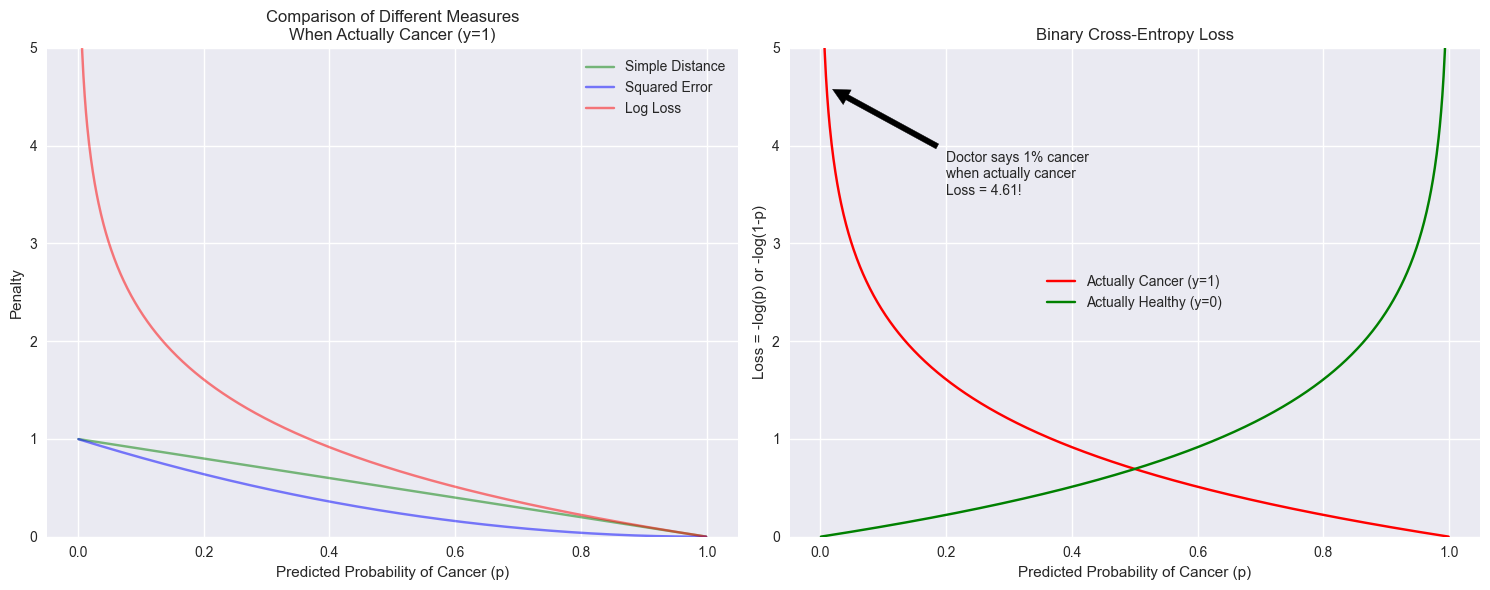

In [9]:
# Calculate log loss
log_loss_cancer = -np.log(probability_of_cancer_array)
log_loss_healthy = -np.log(1-probability_of_cancer_array)

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Compare all three measures for cancer case
ax1.plot(probability_of_cancer_array, error_where_is_cancer_array, 'g-', label='Simple Distance', alpha=0.5)
ax1.plot(probability_of_cancer_array, squared_errors_cancer, 'b-', label='Squared Error', alpha=0.5)
ax1.plot(probability_of_cancer_array, log_loss_cancer, 'r-', label='Log Loss', alpha=0.5)

ax1.set_title('Comparison of Different Measures\nWhen Actually Cancer (y=1)')
ax1.set_xlabel('Predicted Probability of Cancer (p)')
ax1.set_ylabel('Penalty')
ax1.set_ylim(0, 5)
ax1.grid(True)
ax1.legend()

# Plot 2: Log Loss for both cases
ax2.plot(probability_of_cancer_array, log_loss_cancer, 'r-', label='Actually Cancer (y=1)')
ax2.plot(probability_of_cancer_array, log_loss_healthy, 'g-', label='Actually Healthy (y=0)')

ax2.set_title('Binary Cross-Entropy Loss')
ax2.set_xlabel('Predicted Probability of Cancer (p)')
ax2.set_ylabel('Loss = -log(p) or -log(1-p)')
ax2.set_ylim(0, 5)

ax2.annotate('Doctor says 1% cancer\nwhen actually cancer\nLoss = 4.61!',
             xy=(0.01, 4.61), xytext=(0.2, 3.5),
             arrowprops=dict(facecolor='black', shrink=0.05))

ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

<a name="binary-cross-entropy-loss"></a>
### Binary cross-entropy loss

Binary cross-entropy loss is the most common loss function for binary classification problems.

It combines two logarithmic loss terms to measure the difference between predicted probabilities and true labels, accounting for both positive (y=1) and negative (y=0) outcomes.

When y=1, it measures how close the prediction is to 1 using -log(p), and when y=0, it measures how close the prediction is to 0 using -log(1-p). These terms are combined into a single loss function:

#### Binary cross-entropy loss formula
#### $Loss(y,p) = -(y \log(p) + (1-y)\log(1-p))$

where:
- $y$ is the true label (0 or 1)
- $p$ is the predicted probability
- $Loss$ is the resulting loss


Looking at the graphs, we can see key properties:

1. Infinite punishment for confident mistakes
   When actually cancer (y=1):
   ```
   p → 0:  Loss → ∞
   ```
   When actually healthy (y=0):
   ```
   p → 1:  Loss → ∞
   ```

2. Reward for appropriate confidence
   When actually cancer (y=1):
   ```
   p = 0.99:  Loss = 0.01  (Excellent!)
   p = 0.50:  Loss = 0.69  (Meh)
   p = 0.01:  Loss = 4.61  (Terrible!)
   ```

3. Smooth gradients for learning
   ```python
   - No sudden jumps or cliffs
   - Clear direction for improvement
   - Always differentiable (good for calculus)
   ```

Note: In practice, we must clip our probability values to prevent numerical instability:
```python
# Clip probability values to prevent numerical instability in the loss function
# Lower bound: epsilon (tiny positive number) prevents log(0) which is -∞
# Upper bound: (1-epsilon) prevents log(1-1) which is also log(0)
epsilon = 1e-15
p = np.clip(p, epsilon, 1 - epsilon)

# Now our loss will stay within computable bounds
loss = -(y * np.log(p) + (1-y) * np.log(1-p))
```

<a name="asymmetric-loss-when-mistakes-arent-equal"></a>
### Asymmetric loss: When mistakes aren't equal

In medical diagnosis, missing cancer is worse than a false alarm. We can modify our loss function:

```python
# First clip probabilities for numerical stability
epsilon = 1e-15
p = np.clip(p, epsilon, 1 - epsilon)

# Then apply asymmetric weights
alpha = 10.0  # Cost of missing cancer
beta = 1.0    # Cost of false alarm

# Calculate asymmetric loss
asymmetric_loss = -(alpha * y * np.log(p) + beta * (1-y) * np.log(1-p))
```

### Visualising asymmetric loss vs regular binary cross-entropy loss

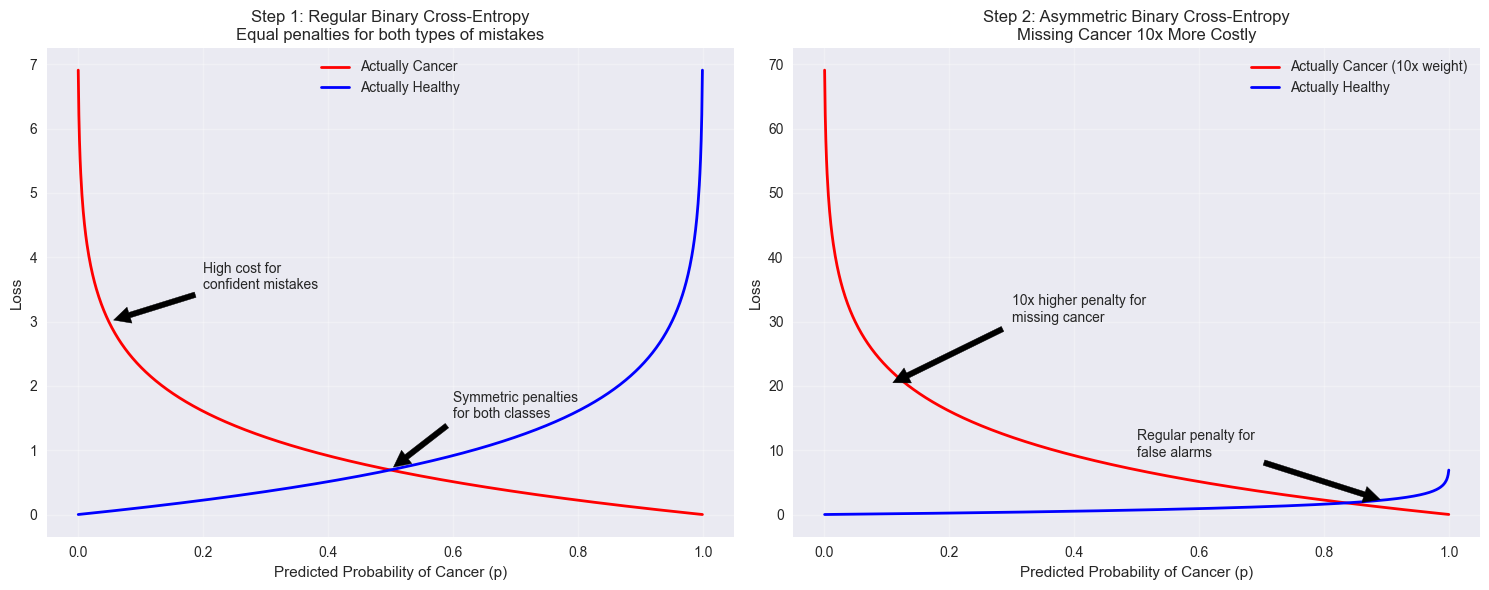

In [10]:
def asymmetric_cross_entropy(p, y, alpha=10.0, beta=1.0):
    """Calculate asymmetric binary cross-entropy loss"""
    return -(alpha * y * np.log(p) + beta * (1-y) * np.log(1-p))

# Generate predictions from 0.001 to 0.999 (avoid log(0))
p = np.linspace(0.001, 0.999, 1000)

# Calculate regular and asymmetric loss
loss_cancer = -(1 * np.log(p))  # Regular BCE for y=1
loss_healthy = -(1 * np.log(1-p))  # Regular BCE for y=0
loss_cancer_asym = asymmetric_cross_entropy(p, y=1, alpha=10.0, beta=1.0)
loss_healthy_asym = asymmetric_cross_entropy(p, y=0, alpha=10.0, beta=1.0)

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Regular BCE
ax1.plot(p, loss_cancer, 'r-', label='Actually Cancer', linewidth=2)
ax1.plot(p, loss_healthy, 'b-', label='Actually Healthy', linewidth=2)
ax1.set_title('Step 1: Regular Binary Cross-Entropy\nEqual penalties for both types of mistakes')
ax1.set_xlabel('Predicted Probability of Cancer (p)')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add key points annotations for regular BCE
ax1.annotate('High cost for\nconfident mistakes',
            xy=(0.05, 3), xytext=(0.2, 3.5),
            arrowprops=dict(facecolor='black', shrink=0.05))
ax1.annotate('Symmetric penalties\nfor both classes',
            xy=(0.5, 0.7), xytext=(0.6, 1.5),
            arrowprops=dict(facecolor='black', shrink=0.05))

# Asymmetric BCE (α=10, β=1)
ax2.plot(p, loss_cancer_asym, 'r-', label='Actually Cancer (10x weight)', linewidth=2)
ax2.plot(p, loss_healthy_asym, 'b-', label='Actually Healthy', linewidth=2)
ax2.set_title('Step 2: Asymmetric Binary Cross-Entropy\nMissing Cancer 10x More Costly')
ax2.set_xlabel('Predicted Probability of Cancer (p)')
ax2.set_ylabel('Loss')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Add key points annotations for asymmetric BCE
ax2.annotate('10x higher penalty for\nmissing cancer',
            xy=(0.1, 20), xytext=(0.3, 30),
            arrowprops=dict(facecolor='black', shrink=0.05))
ax2.annotate('Regular penalty for\nfalse alarms',
            xy=(0.9, 2), xytext=(0.5, 9),
            arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

Looking at the asymmetric plot:
1. Missing cancer (right plot, red line)
   - Confident mistakes punished 10x more severely
   - This forces the model to be extra careful about cancer cases
<br>
2. False alarms (right plot, blue line)
   - Predicting Cancer when it is not cancer is still punished, but less severely
   - This may be an acceptable trade-off if it helps catch more cancer cases
<br>
In practice:
- Regular BCE works well for balanced problems
- Asymmetric BCE when mistakes have different costs
- Medical diagnosis often uses asymmetric loss

Now that we understand how to measure our model's mistakes using loss functions, let's explore how the model actually learns from these errors.

<a name="gradient-descent-learning-from-our-errors"></a>
## Gradient descent: Learning from our errors

Back to our initial example, of our doctor learning to diagnose cancer.

We know two things:
1. We can measure how wrong we are using the loss function
2. We want to adjust each weight of our model to be less wrong than the value it was set to previously

<a name="step-1-starting-position-and-the-forward-pass"></a>
### Step 1: Starting position and "The Forward Pass"

Our model combines features using weights and adds a bias term:

### $z = weight_1 \times feature_1 + weight_2 \times feature_2 + ... + weight_n \times feature_n + bias$

Initial random weights:
```
weight_size  = 0.3             # Weight for cell size
weight_shape = -0.4            # Weight for cell shape
bias      = 0.0                # Bias term
```

Input features (Standardised):
```
size  = +2.1σ                  # Much bigger than normal (2.1 standard deviations from mean)
shape = +1.9σ                  # Very irregular (1.9 standard deviations from mean)
truth = 1                      # Actually cancer

Note: σ (sigma) represents standard deviation, which measures spread of data
```

### $z = weight_1 \times feature_1 + weight_2 \times feature_2 + ... + weight_n \times feature_n + bias$
```
z = (0.3 × 2.1) + (-0.4 × 1.9) + 0
  = 0.63 - 0.76
  = -0.13                      # This is our score
```
The bias term is like a "baseline suspicion level" - it determines how likely we are to predict cancer even before looking at any measurements. Just as we'll learn the right weights for each feature, we'll also learn the right bias to help minimise our model's loss.

<a name="step-2-sigmoid-activation---making-a-prediction"></a>
### Step 2: Sigmoid activation - making a prediction

### $p = \frac{1}{1 + e^{-z}}$


```
p = 1/(1 + e^(-(-0.13)))      # Convert score to probability using z = -0.13
  = 1/(1 + e^(0.13))          # Simplify negative of negative
  = 0.47                      # 47% chance of cancer (class 1)
                              # Or 53% chance of benign (class 0)
                              # Since p < 0.5, predict benign

```
Note: Model is unsure (close to 0.5)
We'll use symmetric loss (equal penalty for false positives and negatives)

<a name="step-3-measuring-the-error"></a>
### Step 3: Measuring the error

Binary cross-entropy loss formula:
### $Loss = -(y \log(p) + (1-y) \log(1-p))$

Where:
```
y = 1        # True label (cancer)
p = 0.47     # Predicted probability of cancer
```

```
loss = -(y * log(p) + (1-y) * log(1-p))
     = -(1 * log(0.47) + (1-1) * log(1-0.47))
     = -(1 * log(0.47) + 0 * log(1-0.47))
     = -(log(0.47) + 0)
     = 0.755
```

If it had been benign (y=0):
```
loss = -(0 * log(0.47) + 1 * log(1-0.47))
     = -(0 + log(0.53))
     = 0.635  # Smaller loss because prediction
              # was slightly correct (53% benign)
              # But still uncertain (close to 50%)
```

<a name="step-4-calculating-the-gradient-of-loss-for-each-parameter"></a>
### Step 4: Calculating the gradient of loss for each parameter

To know how to adjust our weights and bias, we need to calculate the gradient (slope) of the loss with respect to each parameter.

Note: ∂ (partial derivative) shows how one variable changes when we adjust another while holding other variables constant

The gradient tells us:
1. In which direction to move each parameter (positive/negative) to reduce our prediction error.
2. How big of a step to take (magnitude) to reduce our prediction error.

For weights, the gradient equation is:
### $ \frac{\partial Loss}{\partial weight_i} = (predicted\_outcome - actual\_outcome) * feature\_input\_value $

For bias, the gradient equation is simpler:
### $ \frac{\partial Loss}{\partial bias} = (predicted\_outcome - actual\_outcome) $

Let's calculate for our example:

```
predicted_outcome = 0.47    # Our prediction
actual_outcome = 1          # Actually cancer
```

Gradient of Loss with respect to the Weight of size:
```
feature_input_value = 2.1
∂Loss/∂w_size       = (0.47 - 1) * 2.1
                    = -0.53 * 2.1
                    = -1.113
```

Gradient of Loss with respect to the Weight of shape:
```
feature_input_value = 1.9
∂Loss/∂w_shape      = (0.47 - 1) * 1.9
                    = -0.53 * 1.9
                    = -1.007
```

Gradient of Loss with respect to bias:
```
∂Loss/∂b            = (0.47 - 1)
                    = -0.53
```

These formulae are derived using the chain rule. For both weights and bias:

1. Loss is a function of probability: $Loss(y,p) = -(y \log(p) + (1-y)\log(1-p))$
2. Probability is a function of score: $probability = \frac{1}{1 + e^{-score}}$
3. Score is a function of weights and bias: $score = w_1 \cdot input_1 + w_2 \cdot input_2 + bias$

This creates a chain of dependencies:
weights/bias → score → probability → loss

To find how changes in weights affect loss, we multiply these relationships together using the chain rule.

**Gradient of Loss with respect to the Weight:**
## $ \require{cancel} \frac{\partial Loss}{\partial weight} = \frac{\partial Loss}{\partial probability} \cdot \frac{\partial probability}{\partial score} \cdot \frac{\partial score}{\partial weight} $
## $ \require{cancel} \frac{\partial Loss}{\partial weight} = \frac{\partial Loss}{\cancel{\partial prob}} \cdot \frac{\cancel{\partial prob}}{\cancel{\partial score}} \cdot \frac{\cancel{\partial score}}{\partial weight} $

**Gradient of Loss with respect to Bias:**
## $ \require{cancel} \frac{\partial Loss}{\partial bias} = \frac{\partial Loss}{\partial probability} \cdot \frac{\partial probability}{\partial score} \cdot \frac{\partial score}{\partial bias} $
## $ \require{cancel} \frac{\partial Loss}{\partial bias} = \frac{\partial Loss}{\cancel{\partial prob}} \cdot \frac{\cancel{\partial prob}}{\cancel{\partial score}} \cdot \frac{\cancel{\partial score}}{\partial bias} $

The next section dives into how we derived these formulas by finding the derivatives of each of our functions and simplifying using the chain rule.

Feel free to skip to the next section if you're not interested in the derivation math.

<a name="step-4---the-calculus-how-gradient-of-loss-with-respect-to-each-parameter-is-derived-using-the-chain-rule"></a>
### Step 4 - The Calculus: How gradient of loss with respect to each parameter is derived using the Chain Rule


                                                
#### Differentiation rules & formulae               

**Sum Rule:**
$\frac{d}{dx}[f(x) + g(x)] = \frac{d}{dx}f(x) + \frac{d}{dx}g(x)$

**Constant Multiple Rule:**
$\frac{d}{dx}[c \cdot f(x)] = c \cdot \frac{d}{dx}f(x)$

**Product Rule:**
$\frac{d}{dx}[f(x)g(x)] = f'(x)g(x) + f(x)g'(x)$

**Chain Rule:**
$\frac{d}{dx}f(g(x)) = f'(g(x)) \cdot g'(x)$

**Log Rule:**
$\frac{d}{dx}\log(x) = \frac{1}{x}$

**Exponential Rule:**
$\frac{d}{dx}e^x = e^x$

**Quotient Rule:**
$\frac{d}{dx}[\frac{f(x)}{g(x)}] = \frac{f'(x)g(x) - f(x)g'(x)}{[g(x)]^2}$
#### 1. Loss with respect to Probability: ($\frac{\partial Loss}{\partial probability}$)

$ Loss = -(y \cdot \log(probability) + (1-y)\log(1-probability)) $

##### **Differentiate term 1 - using Constant Multiple Rule and Log Rule:**
##### $ -y \cdot \log(probability) $

##### $ \frac{\partial}{\partial probability}(-y \cdot \log(probability)) = -y \cdot \frac{1}{probability} $                                          
##### $ \frac{\partial}{\partial probability}(-y \cdot \log(probability)) = \frac{-y}{probability} $                                                  

##### **Differentiate Term 2 - using Constant Multiple Rule and Chain Rule:**
#####  $-(1-y)\log(1-probability)$

##### $\frac{\partial}{\partial probability}[-(1-y)\log(1-probability)] = -(1-y) \cdot \frac{\partial}{\partial probability}[\log(1-probability)]$   

##### $\frac{\partial}{\partial probability}[-(1-y)\log(1-probability)] = -(1-y) \cdot [\frac{1}{1-probability} \cdot \frac{\partial}{\partial probability}(1-probability)]$                                           

##### $\frac{\partial}{\partial probability}[-(1-y)\log(1-probability)] = -(1-y) \cdot [\frac{1}{1-probability} \cdot (-1)]$                                                                                           

##### $\frac{\partial}{\partial probability}[-(1-y)\log(1-probability)] = \frac{1-y}{1-probability}$                                                                                                                   

##### **Combining terms using Sum Rule:**

##### $ \frac{\partial Loss}{\partial probability} = \frac{-y}{probability} + \frac{1-y}{1-probability}$                                             

---

#### 2. Probability with respect to Score: ($\frac{\partial probability}{\partial score}$)

##### $ probability = \frac{1}{1 + e^{-score}}$

##### **Using Quotient Rule: $\frac{d}{dx}[\frac{f(x)}{g(x)}] = \frac{f'(x)g(x) - f(x)g'(x)}{[g(x)]^2}$**

##### $ \frac{\partial probability}{\partial score} = \frac{(0)(1 + e^{-score}) - (1)(-e^{-score})}{(1 + e^{-score})^2}$

##### $ \frac{\partial probability}{\partial score} = \frac{0 - (-e^{-score})}{(1 + e^{-score})^2}$

##### $ \frac{\partial probability}{\partial score} = \frac{e^{-score}}{(1 + e^{-score})^2}$

##### $ \frac{\partial probability}{\partial score} = \frac{1}{1 + e^{-score}} \cdot \frac{e^{-score}}{1 + e^{-score}}$

##### $ \frac{\partial probability}{\partial score} = probability \cdot \frac{e^{-score}}{1 + e^{-score}}$

##### $ \frac{\partial probability}{\partial score} = probability \cdot \frac{1 + e^{-score} - 1}{1 + e^{-score}}$

##### $ \frac{\partial probability}{\partial score} = probability \cdot (\frac{1 + e^{-score}}{1 + e^{-score}} - \frac{1}{1 + e^{-score}})$

##### $ \frac{\partial probability}{\partial score} = probability \cdot (1 - \frac{1}{1 + e^{-score}})$

##### $ \frac{\partial probability}{\partial score} = probability \cdot (1-probability)$

---

#### 3. Score with respect to Weight ($\frac{\partial score}{\partial weight}$)

##### $ score = weight_1 \cdot input_1 + weight_2 \cdot input_2 + bias $

##### **Using Sum Rule: The derivative of a sum is the sum of derivatives**

##### $ \frac{\partial score}{\partial weight_1} = \frac{\partial}{\partial weight_1}(weight_1 \cdot input_1) + \frac{\partial}{\partial weight_1}(weight_2 \cdot input_2) + \frac{\partial}{\partial weight_1}(bias) $

##### $ \frac{\partial score}{\partial weight_1} = input_1 \cdot \frac{\partial}{\partial weight_1}(weight_1) + input_2 \cdot \frac{\partial}{\partial weight_1}(weight_2) + \frac{\partial}{\partial weight_1}(bias) $

##### $ \frac{\partial score}{\partial weight_1} = input_1 \cdot 1 + input_2 \cdot 0 + 0 $

##### $ \frac{\partial score}{\partial weight_1} = input_1 $

---

#### 4. Score with respect to Bias ($\frac{\partial score}{\partial bias}$)

##### $ score = weight_1 \cdot input_1 + weight_2 \cdot input_2 + bias $

##### **Using Sum Rule: The derivative of a sum is the sum of derivatives**

##### $ \frac{\partial score}{\partial bias} = \frac{\partial}{\partial bias}(weight_1 \cdot input_1) + \frac{\partial}{\partial bias}(weight_2 \cdot input_2) + \frac{\partial}{\partial bias}(bias) $

##### $ \frac{\partial score}{\partial bias} = 0 + 0 + \frac{\partial}{\partial bias}(bias) $

##### $ \frac{\partial score}{\partial bias} = 1 $

---
#### Putting it all together using the chain rule:

#### For weights:
#### $\frac{\partial Loss}{\partial weight} = \frac{\partial Loss}{\partial probability} \cdot \frac{\partial probability}{\partial score} \cdot \frac{\partial score}{\partial weight_1}$

#### $\frac{\partial Loss}{\partial weight_1} = (\frac{-y}{probability} + \frac{1-y}{1-probability}) \cdot probability(1-probability) \cdot input_1$

#### $\frac{\partial Loss}{\partial weight_1} = (\frac{-y \cdot probability(1-probability)}{probability} + \frac{(1-y) \cdot probability(1-probability)}{1-probability}) \cdot input_1$

#### $\require{cancel} \frac{\partial Loss}{\partial weight_1} = (\frac{-y \cdot \cancel{probability}(1-probability)}{\cancel{probability}} + \frac{(1-y) \cdot probability(\cancel{1-probability})}{\cancel{1-probability}}) \cdot input_1$

#### $\frac{\partial Loss}{\partial weight_1} = (-y(1-probability) + (1-y)probability) \cdot input_1$

#### $\require{cancel} \frac{\partial Loss}{\partial weight_1} = (-y + \cancel{yprobability} + probability - \cancel{yprobability}) \cdot input_1$

#### $\frac{\partial Loss}{\partial weight_1} = (-y + probability) \cdot input_1$

#### $\frac{\partial Loss}{\partial weight_1} = (probability - y) \cdot input_1$

#### For bias:
#### $\frac{\partial Loss}{\partial bias} = \frac{\partial Loss}{\partial probability} \cdot \frac{\partial probability}{\partial score} \cdot \frac{\partial score}{\partial bias}$

#### $\frac{\partial Loss}{\partial bias} = (\frac{-y}{probability} + \frac{1-y}{1-probability}) \cdot probability(1-probability) \cdot 1$

#### $\frac{\partial Loss}{\partial bias} = (\frac{-y \cdot probability(1-probability)}{probability} + \frac{(1-y) \cdot probability(1-probability)}{1-probability}) \cdot 1$

#### $\require{cancel} \frac{\partial Loss}{\partial bias} = (\frac{-y \cdot \cancel{probability}(1-probability)}{\cancel{probability}} + \frac{(1-y) \cdot probability(\cancel{1-probability})}{\cancel{1-probability}}) \cdot 1$

#### $\frac{\partial Loss}{\partial bias} = (-y(1-probability) + (1-y)probability) \cdot 1$

#### $\require{cancel} \frac{\partial Loss}{\partial bias} = (-y + \cancel{yprobability} + probability - \cancel{yprobability}) \cdot 1$

#### $\frac{\partial Loss}{\partial bias} = (-y + probability) \cdot 1$

#### $\frac{\partial Loss}{\partial bias} = (probability - y)$

#### Therefore our final results are:
#### $\frac{\partial Loss}{\partial weight_i} = (probability - true\_label) \cdot input_i$
#### $\frac{\partial Loss}{\partial bias} = (probability - true\_label)$

Where y is the true label of the sample and p is the predicted probability of the sample.

---


#### Back to our implementation

The beauty is that whether we have one feature or a thousand, one patient or a million, our core update rules stay the same:
```python
gradient_of_loss_with_respect_to_weight = (predicted_probability - true_label) * feature_input_value
gradient_of_loss_with_respect_to_bias = (predicted_probability - true_label)
```

### Step 4: Calculate the gradient using the derived formula! - The Backward Pass

Recapping on our previous calculations, we calculated the gradient (slope) of the loss with respect to each parameter:

```
For our example, where:
- predicted_probability = 0.47             # 47% cancer
- true_label            = 1                # is cancer
- feature_value         = 2.1              # for feature: size

∂Loss/∂w_size           = (0.47 - 1) * 2.1
                        = -0.53 * 2.1
                        = -1.113

∂Loss/∂w_shape          = (0.47 - 1) * 1.9
                        = -0.53 * 1.9
                        = -1.007

∂Loss/∂bias            = (0.47 - 1)
                        = -0.53
```

<a name="step-5-calculating-the-amount-to-update-each-parameter-by"></a>
### Step 5: Calculating the amount to update each parameter by

We adjust each parameter in the opposite direction of its gradient because the gradient indicates how the loss would change if we slightly increased each parameter.

The learning rate controls how big of a step we take in that direction. For now we'll choose 0.1 as its big enough to learn quickly and small enough to not overshoot the optimal solution.

We'll explore how to choose this value optimally later.

```
learning_rate          = 0.1               # How big of steps to take

w_size_update_amount   = learning_rate * -(∂Loss/∂w_size)
                       = 0.1 * -(-1.113)
                       = 0.1113

w_shape_update_amount  = learning_rate * -(∂Loss/∂w_shape)
                       = 0.1 * -(-1.007)
                       = 0.1007

bias_update_amount     = learning_rate * -(∂Loss/∂bias)
                       = 0.1 * -(-0.53)
                       = 0.053
```

<a name="step-6-updating-the-parameters"></a>
### Step 6: Updating the parameters
```
updated_w_size         = old_w_size + w_size_update_amount
                       = 0.3 + 0.1113
                       = 0.4113

updated_w_shape        = old_w_shape + w_shape_update_amount
                       = -0.4 + 0.1007
                       = -0.2993

updated_bias          = old_bias + bias_update_amount
                       = 0 + 0.053
                       = 0.053
```

<a name="second-pass---step-1-again"></a>
### Second pass - Step 1 again:

Let's see if our updated parameters work better:

```
new_z                  = (updated_w_size × 2.1) + (updated_w_shape × 1.9) + updated_bias
                       = (0.4113 × 2.1) + (-0.2993 × 1.9) + 0.053
                       = 0.864 - 0.569 + 0.053
                       = 0.348

new_p                  = 1/(1 + e^(-0.348))
                       = 0.586                 # Now predicts cancer! (58.6%)
```

The addition of bias helps by:
1. Shifting all predictions up slightly (by 0.053)
2. Learning the base rate of cancer in the population
3. Making the model more flexible - it can learn both feature importance (weights) and general tendency (bias)

<a name="the-learning-process"></a>
### The learning process

<img src="https://github.com/powell-clark/supervised-machine-learning/blob/main/static/images/logistic-regression-cycle.png?raw=1" alt="Logistic Regression Cycle" width="800">

Each iteration consists of:

The Forward Pass:

1. Compute score (z) from features, weights and bias
2. Convert score to probability using sigmoid
3. Calculate loss

The Backward Pass:

4. Compute gradients for each parameter
5. Calculate update amounts using learning rate
6. Update parameters in opposite direction of gradients

Rinse, Repeat for a set number of epochs (iterations)

With each iteration:
- Parameters gradually improve
- Predictions get more accurate
- Loss decreases

This is how our model learns from experience, just like a doctor seeing many patients and learning which signs matter most and how common cancer is in general.

Now let's see how to turn this elegant math into working code...

<a name="implementing-logistic-regression-from-theory-to-code"></a>
## Implementing logistic regression: From theory to code

Below is a basic implementation of logistic regression from scratch. This implementation is a simplified version of the logistic regression model we will be using in our practical lesson. We'll run it on the same breast cancer dataset we used in our practical lesson. We'll explore the dataset in more detail in our practical lesson but for now a basic understanding of the dataset is all we need.

The Wisconsin Breast Cancer Dataset is a classic dataset used for binary classification tasks. It consists of 569 samples with 30 features each, including measurements like radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension, and more. The target variable is binary, indicating whether the cancer is malignant (1) or benign (0).

A display of the dataset is included prior to running our model in the implementation below to help you understand the structure of the data.

In [11]:
# Manual train-test split
def train_test_split_with_stratification(features: np.ndarray, labels: np.ndarray, test_size: float = 0.2, random_seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Manually split data into training and testing sets with optional stratification.

    Args:
        features: A 2D numpy array where each inner array represents one sample's features.
                 Shape: (n_samples, n_features) where each value is a feature measurement.
                 Example: [[1.2, 0.5, 3.1],  # First sample's 3 features
                          [0.8, 1.2, 2.2]]   # Second sample's 3 features
        labels: An array containing the labels that match each row of the input features
        test_size: The proportion of the data to use for testing, ranging from 0 to 1
        random_seed: A number used to ensure the results are reproducible
        stratify: A boolean indicating whether to maintain the same proportion of classes in the split (default is True)

    Returns:
        train_features, test_features, train_labels, test_labels
    """
    np.random.seed(random_seed)
    n_samples = len(features)


    # Get unique label names in this case "0" and "1" from the labels array
    unique_labels = np.unique(labels)

    # Create a dictionary that maps each unique label to the row indices where it appears.
    # note: np.where returns a tuple of arrays, hence np.where()[0]
    label_indices = {label: np.where(labels == label)[0] for label in unique_labels}

    # Calculate number of test samples needed from each class
    test_indices = []
    for label in unique_labels:
        label_count = len(label_indices[label])
        n_test_for_label = int(label_count * test_size)

        # Randomly select indices for this class
        label_test_indices = np.random.choice(
            label_indices[label],
            n_test_for_label,
            replace=False
        )
        test_indices.extend(label_test_indices)


    # Create boolean mask:
    # 1. Create an array of zeros the length of the number of samples
    # 2. Set array indices that are the test samples to true and split data
    is_test = np.zeros(n_samples, dtype=bool)
    is_test[test_indices] = True

    # Split the data using the boolean mask:
    # ~is_test inverts the mask (True becomes False and vice versa)
    # Features/labels where mask is True go to test set
    # Features/labels where mask is False go to train set
    train_features = features[~is_test]
    test_features = features[is_test]
    train_labels = labels[~is_test]
    test_labels = labels[is_test]

    return train_features, test_features, train_labels, test_labels

# Manual standardisation
def standardise_features(train_features: np.ndarray, test_features: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Manually standardise features to normal distribution using training set statistics.

    Args:
        train_features: Training set features
        test_features: Test set features

    Returns:
        standardised_train, standardised_test, means, stds
    """
    # Calculate mean and standard deviation from training data
    feature_means = np.mean(train_features, axis=0)
    feature_standard_deviations = np.std(train_features, axis=0)

    # Avoid division by zero
    # note: in thise case np.where returns an array
    feature_standard_deviations = np.where(feature_standard_deviations == 0, 1e-7, feature_standard_deviations)

    # Standardise both sets using training statistics
    standardised_train = (train_features - feature_means) / feature_standard_deviations
    standardised_test = (test_features - feature_means) / feature_standard_deviations

    return standardised_train, standardised_test, feature_means, feature_standard_deviations

class SimpleLogisticRegression:
    """A basic implementation of logistic regression for binary classification.

    This class implements logistic regression from scratch to help understand the core concepts.
    It uses gradient descent to learn the optimal weights and bias for classification.
    """

    def __init__(self, learning_rate: float = 0.1) -> None:
        """Initialise the model with a learning rate.

        Args:
            learning_rate:  How big of steps to take during gradient descent.
                            Smaller values (like 0.01) mean slower but more stable learning.
                            Larger values (like 0.5) mean faster but potentially unstable learning.
        """
        self.learning_rate = learning_rate
        self.model_weights = None  # Will store the weights (w₁, w₂, etc.) after training
        self.model_bias = None     # Will store the bias term (b) after training

    def calculate_linear_scores(self, feature_matrix: Union[List[List[float]], NDArray[np.float64]]) -> NDArray[np.float64]:
        """Calculate raw linear scores (z) for input features using weights and bias.
        z = w₁x₁ + w₂x₂ + ... + b
        """
        # Convert input to numpy array if needed
        if not isinstance(feature_matrix, np.ndarray):
            feature_matrix = np.array(feature_matrix)

        # Check if model has been trained
        if self.model_weights is None or self.model_bias is None:
            raise ValueError("Model needs to be trained first!")


        # Calculate scores for all samples - (z = w₁x₁ + w₂x₂ + ... + b)
        # - Multiply each feature value by its weight and sum (matrix multiplication)
        # - Add bias term to each sample's score
        return np.dot(feature_matrix, self.model_weights) + self.model_bias

    def convert_scores_to_probabilities(self, scores: NDArray[np.float64]) -> NDArray[np.float64]:
        """Convert raw linear scores to probabilities using sigmoid function.
        probability = 1 / (1 + e^(-z))
        """
        safe_scores = np.clip(scores, -500, 500)  # Prevent numerical overflow
        return 1 / (1 + np.exp(-safe_scores))

    def calculate_probabilities(self, feature_matrix: Union[List[List[float]], NDArray[np.float64]]) -> NDArray[np.float64]:
        """Calculate prediction probabilities for input features."""
        scores = self.calculate_linear_scores(feature_matrix)
        return self.convert_scores_to_probabilities(scores)

    def train_model(self, feature_matrix: Union[List[List[float]], NDArray[np.float64]],
                   target_values: Union[List[float], NDArray[np.float64]],
                   num_epochs: int = 100,
                   show_progress: bool = False) -> List[float]:
        """
        This function trains the logistic regression model on the provided training data.
        It takes in a feature matrix, target values, the number of epochs to train for, and an optional flag to show progress updates.
        The function iterates through the training data for the specified number of epochs
        Each epoch the function determines the binary cross-entropy loss for the current weights and bias
        Then uses gradient descent to calculate the gradient of the loss with respect to the weights and bias
        It updates the weights and bias for the next gradient descent pass
        It returns a list of loss values at each epoch, which can be used to monitor the model's training progress.

        Args:
            feature_matrix: Training features
            target_values: True labels (0 or 1)
            num_epochs: Number of training iterations
            show_progress: Whether to print progress updates

        Returns:
            List of loss values during training
        """
        # Convert inputs to numpy arrays
        feature_matrix = np.array(feature_matrix)
        target_values = np.array(target_values)

        # Basic initialization with small random values
        num_features = feature_matrix.shape[1]
        self.model_weights = np.random.randn(num_features) * 0.01
        self.model_bias = 0.0
        training_loss_history = []

        print(f"Training model for {num_epochs} epochs...")
        for epoch in range(num_epochs):
            # Step 1: Calculate an array of prediction values for each sample row from the matrix of feature values using the weights and bias present on the class
            predictions = self.calculate_probabilities(feature_matrix)

            # Step 2: Ensure numerical stability when calculating loss
            epsilon = 1e-15  # Small number to prevent log(0)
            predictions = np.clip(predictions, epsilon, 1 - epsilon)

            # Step 3: Calculate gradients

            # For weight gradients: (1/num_samples) * features_transposed * (predicted_probabilities - true_labels)
            # 1. feature_matrix = [n_samples_rows × n_features_columns]
            # 2. feature_matrix.T = Transposes the feature matrix so each row is now a feature, aligning it with the prediction values array
            # 3. (predictions - target_values) = We calculate the error of each sample by subtracting the target values array from the predictions values array
            # 4. np.dot multiplies each feature's values by the sample errors and sums them, giving total error contribution for each feature
            # 5. Lastly we divide each gradient in the matrix by the number of samples to get the average gradient for each feature
            average_weight_gradients = np.dot(feature_matrix.T, (predictions - target_values)) / len(target_values)

            # For bias: (1/num_samples) * (predictions - target_values)
            average_bias_gradient = np.mean(predictions - target_values)

            # Step 4: the weight for each feature and the bias are updated by subtracting the learning rate multiplied by the average gradient for each feature and bias
            self.model_weights -= self.learning_rate * average_weight_gradients
            self.model_bias -= self.learning_rate * average_bias_gradient

            # Step 5: Calculate and store loss
            # Using binary cross-entropy loss: -y*log(p) - (1-y)*log(1-p)
            binary_cross_entropy_per_sample = -(
                target_values * np.log(predictions) +
                (1 - target_values) * np.log(1 - predictions)
            )

            average_loss_this_epoch = float(np.mean(binary_cross_entropy_per_sample))

            training_loss_history.append(average_loss_this_epoch)

            # Print progress if requested
            if show_progress and (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1}/{num_epochs}, Loss: {average_loss_this_epoch:.4f}")

        return training_loss_history

    def predict_binary_classes(self, feature_matrix: Union[List[List[float]], NDArray[np.float64]],
                             threshold: float = 0.5) -> NDArray[np.int64]:
        """Convert probability predictions to binary (0/1) predictions based on a threshold with default of 0.5"""
        probabilities = self.calculate_probabilities(feature_matrix)
        return (probabilities >= threshold).astype(int)


# Load the data
cancer_data = load_breast_cancer()
feature_data, target_labels = cancer_data.data, cancer_data.target

# Display the DataFrame
df = pd.DataFrame(
    feature_data[:5],  # First 5 rows
    columns=cancer_data.feature_names  # Column names
)
print("\nWisconsin Breast Cancer Data Scaled:")
display(df)

# train-test split the data
train_features, test_features, train_labels, test_labels = train_test_split_with_stratification(
    feature_data, target_labels, test_size=0.2, random_seed=42
)

# Standardise the data fitting to normal distribution
train_features_scaled, test_features_scaled, feature_means, feature_stds = standardise_features(
    train_features, test_features
)

# Display the Normalised DataFrame
df_scaled = pd.DataFrame(
    train_features_scaled[:5],  # First 5 rows
    columns=cancer_data.feature_names  # Column names
)
print("\nWisconsin Breast Cancer Data Normalised:")
display(df_scaled)

# Create and train the model with standardised data
cancer_classifier = SimpleLogisticRegression(learning_rate=0.01)
training_loss_history = cancer_classifier.train_model(
    train_features_scaled, train_labels,
    num_epochs=1000,
    show_progress=True
)

# Make predictions
training_predictions = cancer_classifier.predict_binary_classes(train_features_scaled)
testing_predictions = cancer_classifier.predict_binary_classes(test_features_scaled)

# Calculate and display accuracy
training_accuracy = float(np.mean(training_predictions == train_labels))
testing_accuracy = float(np.mean(testing_predictions == test_labels))

print("\nModel Performance with Standardised Data:")
print(f"Training Accuracy: {training_accuracy:.4f}")
print(f"Testing Accuracy: {testing_accuracy:.4f}")



Wisconsin Breast Cancer Data Scaled:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Wisconsin Breast Cancer Data Normalised:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.120547,-2.049168,1.290969,1.001153,1.502472,3.338937,2.673515,2.523444,2.242718,2.236895,2.365136,-0.562473,2.704728,2.364768,-0.221405,1.329495,0.684157,0.641754,1.196762,0.973360,1.927532,-1.354699,2.343049,2.048333,1.271615,2.679252,2.169202,2.329392,2.818077,1.960290
1,1.850529,-0.344791,1.705247,1.919190,-0.835282,-0.502159,-0.022342,0.547655,-0.004506,-0.898520,0.465577,-0.865143,0.244527,0.702896,-0.604290,-0.711718,-0.434737,0.250049,-0.842763,-0.106683,1.846157,-0.359050,1.570226,1.936367,-0.390637,-0.438272,-0.139418,1.107864,-0.241860,0.271507
2,1.601543,0.457811,1.586296,1.571748,0.891294,1.066636,1.374901,2.030331,0.946955,-0.426216,1.161680,-0.771552,0.807089,1.120878,-0.302613,0.819759,0.193347,1.388689,0.245237,0.315025,1.549871,-0.011883,1.381513,1.497386,0.501092,1.110077,0.885545,1.984780,1.184788,0.190120
3,-0.738362,0.257161,-0.563849,-0.735774,3.176264,3.460564,1.931269,1.447328,2.901706,4.901429,0.300592,-0.119770,0.266802,-0.278681,0.662753,2.779232,0.775885,1.085792,4.937154,2.197084,-0.257057,0.146962,-0.224942,-0.530987,3.332115,3.985489,2.046481,2.207854,6.185497,5.017959
4,1.771306,-1.135862,1.795486,1.837273,0.245391,0.543447,1.382488,1.424214,-0.015612,-0.591238,1.201635,-0.781441,1.211356,1.129468,1.438959,-0.057236,0.784485,1.114337,-0.379005,0.535823,1.334959,-1.462780,1.372527,1.259235,0.198077,-0.318518,0.638140,0.746329,-0.879967,-0.420283


Training model for 1000 epochs...
Epoch 100/1000, Loss: 0.2559
Epoch 200/1000, Loss: 0.1918
Epoch 300/1000, Loss: 0.1629
Epoch 400/1000, Loss: 0.1459
Epoch 500/1000, Loss: 0.1345
Epoch 600/1000, Loss: 0.1262
Epoch 700/1000, Loss: 0.1199
Epoch 800/1000, Loss: 0.1148
Epoch 900/1000, Loss: 0.1106
Epoch 1000/1000, Loss: 0.1071

Model Performance with Standardised Data:
Training Accuracy: 0.9737
Testing Accuracy: 0.9735


<a name="understanding-our-training-results-through-evaluation"></a>
## Understanding our training results through evaluation

Let's analyse what our model achieved with standardised data:

```
Epoch 100/1000, Loss: 0.2559
Epoch 200/1000, Loss: 0.1918
Epoch 300/1000, Loss: 0.1629
...
Epoch 1000/1000, Loss: 0.1071

Training Accuracy: 0.9737
Testing Accuracy: 0.9735
```

<a name="key-outcomes"></a>
### Key outcomes

1. **Raw numbers**: In medical terms, we correctly diagnosed:
   - Training: ~97% of cases (455 patients)
   - Testing: ~97% of cases (114 new patients)
   - Consistently high performance across both sets!

2. **Loss progression**:
   - Started relatively low (0.25) - standardisation helped initial predictions
   - Steady early improvements (0.25 → 0.18)
   - Continued refinement (0.18 → 0.10)
   - Smooth convergence with minimal fluctuations

<a name="medical-interpretation"></a>
### Medical interpretation

1. **Training like a medical resident with standardised tools**:
   - Started with standardised measurements (like calibrated medical equipment)
   - Learned patterns efficiently due to normalised feature scales
   - Fine-tuned diagnostic skills with consistent metrics
   - Achieved near-expert performance

2. **Diagnostic reliability**:
   - 97% accuracy on new cases is excellent
   - Only ~3% misdiagnosis rate
   - But we still need to understand:
     - Are errors balanced between false positives and negatives?
     - Which type of errors are we making?

The dramatic improvement in both accuracy and loss compared to our non-standardised version demonstrates why feature standardisation is crucial. By normalising our features to a standard scale:
1. The model learned more efficiently
2. Achieved better overall performance
3. Showed more stable training progression

To fully understand our model's clinical value, we need to examine:
1. Different types of diagnostic errors
2. How to measure each type
3. What these measurements mean for patient care

Let's explore these evaluation concepts...

<a name="basic-evaluation-concepts"></a>
## Basic evaluation concepts

When evaluating a binary classification model like our cancer detector, we need multiple metrics to fully understand its performance. Let's break down each key metric:


<a name="1-accuracy"></a>
### 1. Accuracy
The proportion of correct predictions among all predictions:
```python
Accuracy = (True Positives + True Negatives) / Total Predictions
```

Example: If our model correctly identifies 90 out of 100 tumors, the accuracy is 90%.

<a name="2-precision"></a>
### 2. Precision
The proportion of correct positive predictions among all positive predictions:
```python
Precision = True Positives / (True Positives + False Positives)
```

Example: If our model predicts "cancer" for 50 patients and is right for 45 of them:
```python
Precision = 45 / 50 = 90%
```
High precision means few false alarms.

<a name="3-recall-sensitivity"></a>
### 3. Recall (Sensitivity)
The proportion of actual positives correctly identified:
```python
Recall = True Positives / (True Positives + False Negatives)
```

Example: If there are 60 actual cancer cases and our model finds 54 of them:
```python
Recall = 54 / 60 = 90%
```
High recall means few missed cancers.

<a name="4-f1-score"></a>
### 4. F1 Score
The harmonic mean of precision and recall:
```python
F1 = 2 * (Precision * Recall) / (Precision + Recall)
```

Example scenarios:
```python
Scenario 1:
- Precision = 80% (accurate cancer predictions)
- Recall = 60% (catching most cancers)
- F1 = 2 * (0.8 * 0.6) / (0.8 + 0.6) = 0.69

Scenario 2:
- Precision = 70%
- Recall = 70%
- F1 = 2 * (0.7 * 0.7) / (0.7 + 0.7) = 0.70
```
F1 score balances precision and recall.

<a name="the-four-possible-outcomes"></a>
### The four possible outcomes

1. **True Positive (TP)** - Correct Cancer Diagnosis
   ```python
   prediction = "Cancer" (1)
   reality    = "Cancer" (1)
   example: Catching a malignant tumor
   ```

2. **True Negative (TN)** - Correct Healthy Diagnosis
   ```python
   prediction = "Healthy" (0)
   reality    = "Healthy" (0)
   example: Confirming a benign tumor
   ```

3. **False Positive (FP)** - False Alarm
   ```python
   prediction = "Cancer" (1)
   reality    = "Healthy" (0)
   example: Unnecessary biopsy
   cost: Patient anxiety, medical expenses
   ```

4. **False Negative (FN)** - Missed Cancer
   ```python
   prediction = "Healthy" (0)
   reality    = "Cancer" (1)
   example: Missed malignant tumor
   cost: Delayed treatment, potentially fatal
   ```

<a name="the-problem-with-simple-accuracy"></a>
### The problem with simple accuracy

Consider two models on 100 patients (20 with cancer, 80 healthy):

```pre
Model A: 97% Accuracy
- Catches 17/20 cancers
- Correctly identifies 80/80 healthy
- Accuracy = (17 + 80)/100 = 97%
- But misses 3 cancers!

Model B: 95% Accuracy
- Catches 19/20 cancers
- Correctly identifies 76/80 healthy
- Accuracy = (19 + 76)/100 = 95%
- Only misses 1 cancer
```

In medical contexts, Model B might be preferable despite lower accuracy because missing cancer (false negatives) is more dangerous than false alarms (false positives).

<a name="the-confusion-matrix"></a>
### The confusion matrix

To visualise all these metrics at once, we use a confusion matrix:

```pre
                  Predicted
               Healthy │ Cancer
Actual  Healthy   TN   │   FP
        Cancer    FN   │   TP
```

Example confusion matrix for Model B:
```pre
                  Predicted
               Healthy │ Cancer
Actual  Healthy   76   │   4
        Cancer     1   │   19
```

From this matrix we can calculate:
- Accuracy = (76 + 19)/100 = 95%
- Precision = 19/(19 + 4) = 83%
- Recall = 19/(19 + 1) = 95%
- F1 Score = 2 * (0.83 * 0.95)/(0.83 + 0.95) = 0.88


Detailed Model Evaluation Results:
----------------------------------------

Confusion Matrix Details:
True Negatives (Correct Benign):     41
False Positives (False Alarms):      1
False Negatives (Missed Cancers):    2
True Positives (Caught Cancers):     69

Performance Metrics:
Precision       0.9857
Recall          0.9718
F1 Score        0.9787
Accuracy        0.9735

Medical Impact Analysis:
Miss Rate:         2.8% of cancers missed
False Alarm Rate:  2.4% of healthy cases


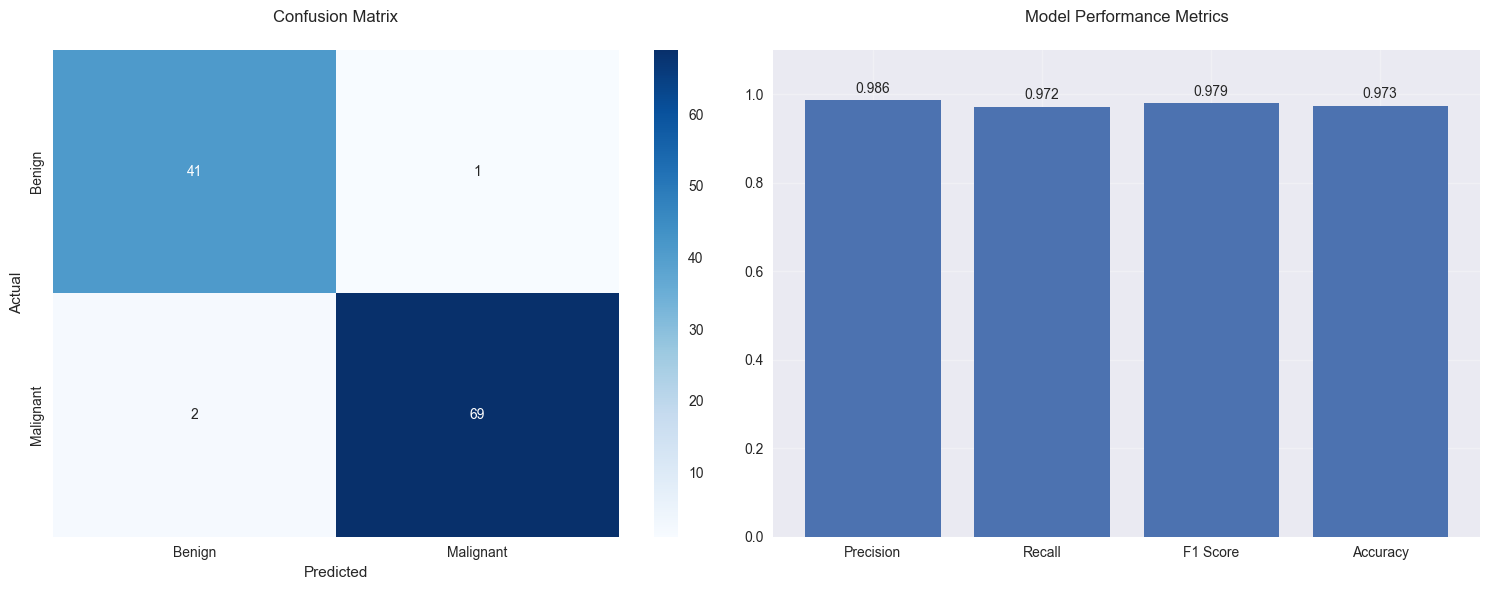

In [12]:
# Calculate and display detailed evaluation metrics
def analyse_and_plot_results():
    # Calculate confusion matrix and metrics
    cm = confusion_matrix(test_labels, testing_predictions)
    tn, fp, fn, tp = cm.ravel()

    # Calculate all metrics
    metrics = {
        'Precision': precision_score(test_labels, testing_predictions),
        'Recall': recall_score(test_labels, testing_predictions),
        'F1 Score': f1_score(test_labels, testing_predictions),
        'Accuracy': accuracy_score(test_labels, testing_predictions)
    }

    # Print detailed analysis
    print("Detailed Model Evaluation Results:")
    print("-" * 40)
    print("\nConfusion Matrix Details:")
    print(f"True Negatives (Correct Benign):     {tn}")
    print(f"False Positives (False Alarms):      {fp}")
    print(f"False Negatives (Missed Cancers):    {fn}")
    print(f"True Positives (Caught Cancers):     {tp}")

    print("\nPerformance Metrics:")
    for metric, value in metrics.items():
        print(f"{metric:15} {value:.4f}")

    # Calculate and print medical impact rates
    false_negative_rate = fn / (fn + tp)
    false_positive_rate = fp / (fp + tn)

    print("\nMedical Impact Analysis:")
    print(f"Miss Rate:         {false_negative_rate:.1%} of cancers missed")
    print(f"False Alarm Rate:  {false_positive_rate:.1%} of healthy cases")

    # Create figure with two subplots
    plt.figure(figsize=(15, 6))

    # Plot 1: Confusion Matrix (left subplot)
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'])
    plt.title('Confusion Matrix', pad=20)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # Plot 2: Performance Metrics (right subplot)
    plt.subplot(1, 2, 2)
    bars = plt.bar(metrics.keys(), metrics.values())
    plt.title('Model Performance Metrics', pad=20)
    plt.ylim(0, 1.1)  # Give some space for value labels
    plt.grid(True, alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}',
                ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    return metrics, false_negative_rate, false_positive_rate

# Generate visualisation and store results
metrics, miss_rate, false_alarm_rate = analyse_and_plot_results()

<a name="understanding-our-models-performance"></a>
## Understanding our model's performance

Let's analyse what these numbers mean for real-world medical diagnosis:

### The good news

1. **Very high precision (0.986)**
   - Nearly zero false alarms (only 1 false positive)
   - 98.6% confidence when we predict cancer
   - Minimal unnecessary biopsies or patient distress

2. **Exceptional overall accuracy (97.35%)**
   - 110 correct diagnoses out of 113 cases
   - Performing significantly above random chance (50%)
   - Strong performance for clinical applications

### The challenges

1. **Recall/Sensitivity (0.972)**
   - Caught 69 cancers, but missed 2
   - 2.8% miss rate on malignant cases
   - Each miss is clinically significant

2. **Diagnosis breakdown**
   ```
   Total Cases:  113
   - Benign:     42 (41 correct, 1 false alarm)
   - Malignant:  71 (69 caught, 2 missed)
   ```

### Clinical implications

1. **Balanced diagnosis**
   - Model demonstrates high trustworthiness
   - Strong balance between caution and sensitivity
   - Effective precision-recall trade-off

2. **Performance metrics**
   - Current miss rate at 2.8%
   - False positive rate at 2.4%
   - F1 Score of 0.979 indicates balanced performance

### Next steps

The results suggest two key areas for investigation:

1. **Learning rate analysis**
   - Evaluate current learning rate effectiveness
   - Investigate optimal learning rate settings
   - Consider impact on edge cases

2. **Decision threshold assessment**
   - Analyse current threshold performance
   - Evaluate threshold optimisation options
   - Study precision-recall trade-off implications

Let's explore how different learning rates affect these metrics...


Learning Rate Comparison Results:

Learning Rate   Final Loss   Accuracy  Miss Rate
--------------------------------------------------
Training model for 1000 epochs...


       1.000       0.0495      0.982      1.4%
Training model for 1000 epochs...
       0.001       0.2569      0.947      5.6%
Training model for 1000 epochs...
       0.100       0.0633      0.973      1.4%
Training model for 1000 epochs...


       0.010       0.1073      0.973      2.8%


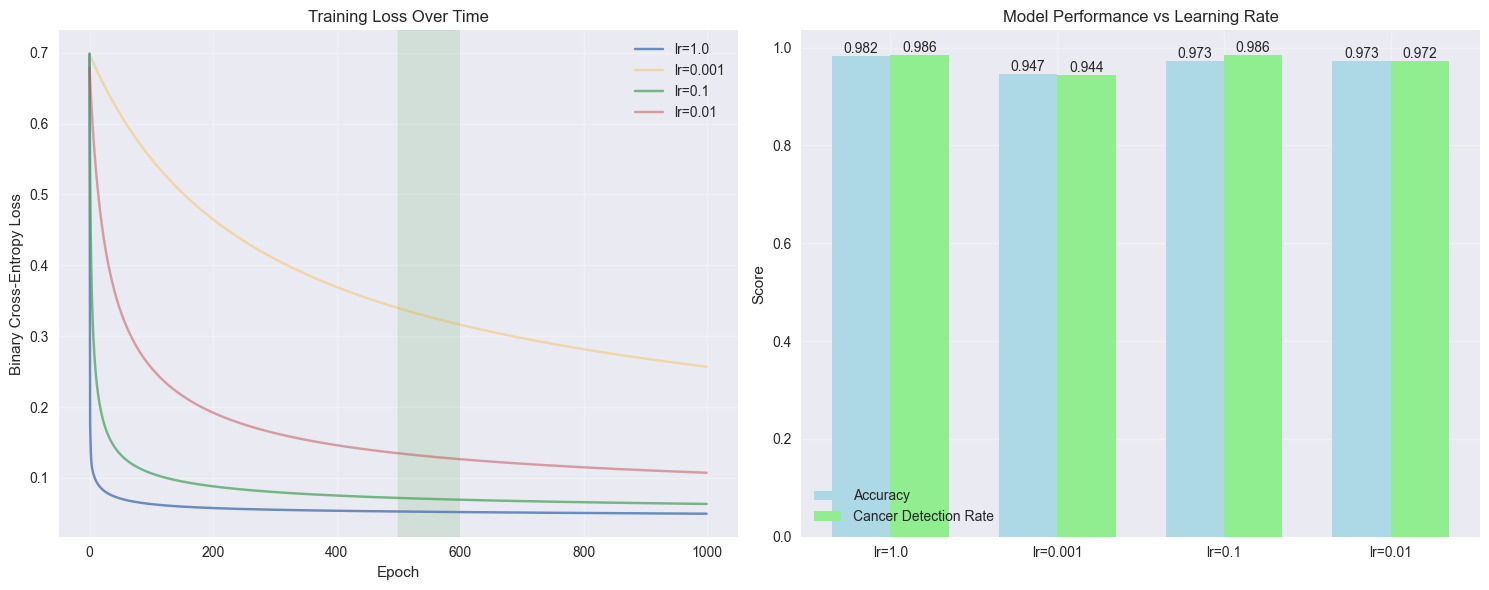

In [13]:
def compare_learning_rates():
    # Define learning rates to test
    learning_rates = [1.0, 0.001, 0.1, 0.01]
    results = []

    # Create figure for two plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    print("Learning Rate Comparison Results:\n")
    print(f"{'Learning Rate':>12} {'Final Loss':>12} {'Accuracy':>10} {'Miss Rate':>10}")
    print("-" * 50)

    # Test each learning rate
    for lr in learning_rates:
        # Train model
        model = SimpleLogisticRegression(learning_rate=lr)
        loss_history = model.train_model(
            train_features_scaled,
            train_labels,
            num_epochs=1000,
            show_progress=False
        )

        # Get predictions
        test_preds = model.predict_binary_classes(test_features_scaled)

        # Calculate metrics
        accuracy = accuracy_score(test_labels, test_preds)
        cm = confusion_matrix(test_labels, test_preds)
        fn = cm[1][0]  # False negatives
        tp = cm[1][1]  # True positives
        miss_rate = fn / (fn + tp)

        # Store results
        results.append({
            'lr': lr,
            'loss_history': loss_history,
            'final_loss': loss_history[-1],
            'accuracy': accuracy,
            'miss_rate': miss_rate
        })

        print(f"{lr:12.3f} {loss_history[-1]:12.4f} {accuracy:10.3f} {miss_rate:9.1%}")

        # Plot learning curves with semi-transparent colours
        if lr == 1.0:
            ax1.plot(loss_history, label=f'lr={lr}', color='#4C72B0', alpha=0.8)  # Deep blue
        elif lr == 0.001:
            ax1.plot(loss_history, label=f'lr={lr}', color='orange', alpha=0.3)  # Burnt orange
        elif lr == 0.1:
            ax1.plot(loss_history, label=f'lr={lr}', color='#55A868', alpha=0.8)  # Forest green
        elif lr == 0.01:
            ax1.plot(loss_history, label=f'lr={lr}', color='#C44E52', alpha=0.5)  # Deep red

    # Configure loss plot
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Binary Cross-Entropy Loss')
    ax1.set_title('Training Loss Over Time')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Highlight convergence region of optimal rate
    ax1.axvspan(500, 600, color='green', alpha=0.1, label='Convergence Region')
    ax1.annotate('Optimal Rate\nConverges Here',
                xy=(550, 3),
                xytext=(400, 1.5),
                arrowprops=dict(facecolor='orange', shrink=0.05))

    # Plot comparison metrics
    metrics = np.array([(r['accuracy'], 1-r['miss_rate']) for r in results])
    x = np.arange(len(learning_rates))
    width = 0.35

    ax2.bar(x - width/2, metrics[:, 0], width, label='Accuracy', color='lightblue' )
    ax2.bar(x + width/2, metrics[:, 1], width, label='Cancer Detection Rate', color='lightgreen')

    # Configure metrics plot
    ax2.set_xticks(x)
    ax2.set_xticklabels([f'lr={lr}' for lr in learning_rates])
    ax2.set_ylabel('Score')
    ax2.set_title('Model Performance vs Learning Rate')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Add value labels on bars
    for i in range(len(learning_rates)):
        ax2.text(i - width/2, metrics[i,0], f'{metrics[i,0]:.3f}',
                 ha='center', va='bottom')
        ax2.text(i + width/2, metrics[i,1], f'{metrics[i,1]:.3f}',
                 ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    return results

# Run comparison and store results
lr_comparison_results = compare_learning_rates()

<a name="understanding-learning-rate-effects"></a>
## Understanding learning rate effects

Just like a doctor learning to read medical scans, our model's learning speed (controlled by the learning rate) dramatically affects how well it learns to spot cancer. Let's decode the fascinating patterns in our training graphs:

<a name="reading-the-loss-curves"></a>
### Reading the loss curves

Our training plots reveal four distinct learning patterns:

1. **Large learning rate (lr=1.0, blue)**:
   - Bold, confident steps in learning
   - Like a resident who quickly grasps key patterns
   - Achieves lowest final loss (0.0495)
   - Outstanding accuracy of 98.2%

2. **Medium learning rate (lr=0.1, green)**:
   - Steady, purposeful learning progression
   - Similar to an efficient clinician methodically building expertise
   - Effective final performance (loss: 0.0634)
   - Strong 97.3% accuracy

3. **Moderate learning rate (lr=0.01, red)**:
   - More cautious learning approach
   - Like a careful practitioner double-checking their assessments
   - Moderate final loss (0.1074)
   - Achieves solid 97.3% accuracy

4. **Small learning rate (lr=0.001, orange)**:
   - Most conservative learning style
   - Akin to an over-cautious doctor requiring extensive confirmation
   - Highest final loss (0.2550)
   - Still reaches 95.6% accuracy

<a name="understanding-the-clinical-impact"></a>
### Understanding the clinical impact

Let's translate these numbers into real medical outcomes:

| Learning Rate | Accuracy | Miss Rate | Clinical Interpretation |
|--------------|----------|-----------|------------------------|
| 1.0 | 98.2% | 1.4% | Almost perfect detection |
| 0.1 | 97.3% | 1.4% | Equally reliable |
| 0.01 | 97.3% | 2.8% | Slightly more missed cases |
| 0.001 | 95.6% | 5.6% | Highest miss rate |

In practical terms:
- Faster learning rates catch significantly more cancers
- Only 1.4% missed cases at higher rates vs 5.6% at lowest rate
- Higher rates show better overall performance

<a name="theoretical-insights-vs-clinical-reality"></a>
### Theoretical insights vs clinical reality

Our model's exceptional performance with high learning rates is particularly interesting. In machine learning practice, using rates like 1.0 or 0.1 often leads to unstable training - like a student who jumps to conclusions too quickly. Our implementation achieves unusual stability at high rates because:

1. **Well-structured problem**
   - Binary classification (cancer/no cancer)
   - Clean, preprocessed medical data
   - Clear decision boundaries

2. **Careful implementation**
   - Gradient averaging across batches
   - Proper weight initialisation
   - Numerically stable computations

This performance demonstrates how well-structured medical data, combined with careful implementation, can enable surprisingly rapid learning.

<a name="key-lessons-about-machine-learning"></a>
### Key lessons about machine learning

Our experiments reveal three fundamental insights:

1. **Speed vs accuracy trade-off**
   - Faster learning can achieve both quicker convergence and better results
   - But stability is crucial - especially in medical applications
   - Need to balance speed with reliability

2. **The value of experimentation**
   - Different learning rates reveal different model behaviours
   - No universal "best" learning rate
   - Always test multiple rates for your specific case

3. **Clinical significance**
   - Learning rate directly impacts missed diagnoses
   - Higher rates (when stable) catch more cancers
   - Real-world impact of parameter choices

<a name="in-practice-a-note-of-caution"></a>
### In practice: A note of caution

While our implementation shows excellent performance at high learning rates, most production systems opt for more conservative approaches:

- Lower base learning rates (0.01 or 0.001)
- Learning rate scheduling (gradually decreasing rates)
- Adaptive optimisation methods (like Adam or RMSprop)
- Multiple training runs with different parameters

This conservative approach ensures reliability across:
- Different types of medical data
- Varying problem complexities
- Production deployment scenarios

<a name="the-big-picture"></a>
### The big picture

Just as doctors develop their diagnostic skills at different rates, our model's learning speed significantly impacts its performance. While our implementation demonstrates exceptional stability at high learning rates, the key principles remain:

1. Test multiple learning approaches
2. Monitor performance carefully
3. Prioritise reliability in medical applications
4. Let empirical results guide your choices

These insights into learning rates complete our understanding of how logistic regression learns from data. Now, let's look back at everything we've created...

<a name="conclusion-our-journey-through-logistic-regression"></a>
## Conclusion: Our journey through logistic regression

In this lesson, we've achieved something remarkable: we built a logistic regression classifier completely from scratch, understanding every component from first principles. Let's reflect on this journey and its significance.

### Building from ground up

Starting with nothing but basic Python and NumPy, we created three core elements:

1. **A complete medical classifier**  
   We built a breast cancer diagnostic system achieving over 97% accuracy on the Wisconsin Breast Cancer dataset. From implementing the sigmoid function to gradient descent calculations, we crafted each component to detect cancer effectively and reliably.

2. **Rich visualisation tools**  
   We developed tools to see our model in action, from 2D and 3D decision boundaries to dynamic training visualizations. These visuals helped us understand not just what our model was doing, but why it made specific diagnostic decisions - critical for medical applications.

3. **Robust evaluation framework**  
   We created comprehensive tools to measure our model's clinical performance, helping us understand its strengths and potential improvements. This wasn't just about accuracy - we looked at precision, recall, and how our model performs across different medical scenarios.

### Deep mathematical understanding

Beyond just writing code, we developed a thorough understanding of the mathematical foundations:

1. **Core mathematical concepts**  
   We unraveled complex ideas like the sigmoid function and binary cross-entropy, seeing how these mathematical tools help us make accurate predictions. Each equation became more than just symbols - they became practical tools we could use to detect cancer.

2. **Optimisation and data preparation**  
   We explored critical concepts like learning rates, gradient descent, and proper data scaling. We saw how standardizing features to common scales dramatically improves model training and performance - essential for combining diverse medical measurements like cell size and shape.

3. **Real-world applications**  
   We learned when to apply logistic regression and how to prepare different types of medical data. These practical insights help us bridge the gap between mathematical theory and real-world medical diagnosis.

### Comprehensive Evaluation Framework

Our deep dive into model evaluation revealed crucial insights for medical applications:

1. **Beyond simple accuracy**
   - Why 97% accuracy isn't always better than 95%
   - The importance of understanding different types of errors
   - How to balance false positives against false negatives in medical contexts

2. **Critical medical metrics**
   - Precision: Minimizing unnecessary biopsies
   - Recall: Catching as many cancer cases as possible
   - F1 Score: Balancing precision and recall for optimal patient care

3. **Understanding error patterns**
   - Using confusion matrices to analyse misdiagnoses
   - Identifying which types of cases our model struggles with
   - Strategies for improving detection of difficult cases

### Understanding our implementation's limitations

While building from scratch was incredibly educational, it's important to understand what our implementation can't do yet. Think of it like building a medical device by hand - you learn how everything works, but it won't have all the features of a professional system.

Our model's current limitations include:
- Binary decisions only (cancer/no cancer)
- Basic optimisation methods
- Limited scalability for large datasets
- No built-in cross-validation
- Simple learning rate management

Modern machine learning libraries offer sophisticated features like:
- Multi-class classification
- Automated hyperparameter tuning
- Efficient large-scale training
- Advanced optimisation algorithms
- Comprehensive validation tools

<a name="looking-ahead-to-lesson-1b"></a>
### Looking ahead to Lesson 1B: Logistic Regression PyTorch Practical

In our next lesson, we'll build on this foundation by exploring modern machine learning libraries. While our from-scratch implementation taught us the fundamentals, we'll now learn how tools like Scikit-learn and PyTorch can help us build more sophisticated medical diagnostic models.

We'll focus on practical aspects like:
- Using optimised implementations for better performance
- Handling larger medical datasets efficiently
- Implementing advanced training techniques
- Preparing models for clinical deployment
- Robust validation for medical applications

### Next lesson: [1B_logistic_regression_practical.ipynb](./1b_logistic_regression_practical.ipynb)

<a name="further-reading"></a>

### Further reading

For those interested in diving deeper:

1. **Mathematical foundations**
   - ["Introduction to Statistical Learning"](https://www.statlearning.com/) by James, Witten, Hastie, and Tibshirani (Chapter 4)
   - ["Pattern Recognition and Machine Learning"](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf) by Bishop (Chapter 4)

2. **Practical implementation**
   - [Stanford CS229 Course Notes](https://cs229.stanford.edu/notes2022fall/main_notes.pdf)
   - [Scikit-learn Documentation](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)

3. **Advanced topics**
   - ["Deep Learning"](https://www.deeplearningbook.org/) by Goodfellow, Bengio, and Courville (Chapter 6.2)
   - ["Machine Learning in Medical Imaging"](https://www.springer.com/gp/book/9783030139681) by Zhou, Greenspan, and Shen

4. **Online resources**
   - [CS231n Stanford Course Notes](http://cs231n.github.io/)
   - [Distill.pub's Visual Intro to Machine Learning](https://distill.pub/)
   - [Medical ML Best Practices](https://www.nature.com/articles/s41591-018-0300-7)

Remember: While building a model from scratch was challenging, it gives us a deep understanding that will serve us well as we move into more advanced medical applications. In the next lesson, we'll see how modern tools can help us build on this foundation while keeping the insights we've gained - always with the goal of improving patient care through better diagnostic tools.


### Thanks for learning!

This notebook is part of the Supervised Machine Learning from First Principles series.

© 2025 Powell-Clark Limited. Licensed under Apache License 2.0.

If you found this helpful, please cite as:
```
Powell-Clark (2025). Supervised Machine Learning from First Principles.
GitHub: https://github.com/powell-clark/supervised-machine-learning
```

Questions or feedback? Contact emmanuel@powellclark.com